# Projeto de predição de preços de Airbnb no Rio de Janeiro

Nosso objetivo com este projeto é gerar modelos capazes de estimar o preço de um Airbnb no Rio de Janeiro dadas as características de um determinado imóvel, como localização, sazonalidade ,tamanho do imóvel entre outras variáveis que veremos a seguir.

### Importação das bibliotecas

In [1]:
import pandas as pd
import pathlib 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from sklearn.metrics import r2_score , mean_squared_error, mean_absolute_error

In [2]:
caminho_base = pathlib.Path(r"archive")
dic_meses = {
    "jan" : '01',
    "fev" : '02',
    "mar" : '03',
    "abr" : '04',
    "mai" : '05',
    "jun" : '06',
    "jul" : '07',
    "ago" : '08',
    "set" : '09',
    "out" : '10',
    "nov" : '11',
    "dez" : '12'
}

Bases_df = pd.DataFrame()
for arquivo in caminho_base.iterdir():
    nome_mes = arquivo.name[:3]
    mes = dic_meses[nome_mes]
    ano = arquivo.name[-8:-4]
    df = pd.read_csv(caminho_base / arquivo.name)  
    df["mes"] = mes
    df["ano"] = ano 
    Bases_df = pd.concat([Bases_df , df])
    
    
    

C:\Users\vitor\AppData\Local\Temp\ipykernel_5124\3218967926.py:22: DtypeWarning: Columns (0: monthly_price, 1: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_base / arquivo.name)
C:\Users\vitor\AppData\Local\Temp\ipykernel_5124\3218967926.py:22: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_base / arquivo.name)
C:\Users\vitor\AppData\Local\Temp\ipykernel_5124\3218967926.py:22: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_base / arquivo.name)


In [3]:
display(Bases_df.head())

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,14063,https://www.airbnb.com/rooms/14063,20180414160018,2018-04-14,Living in a Postcard,"Besides the most iconic's view, our apartment ...",NaN,"Besides the most iconic's view, our apartment ...",none,Best and favorite neighborhood of Rio. Perfect...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17878,https://www.airbnb.com/rooms/17878,20180414160018,2018-04-14,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24480,https://www.airbnb.com/rooms/24480,20180414160018,2018-04-14,Nice and cozy near Ipanema Beach,My studio is located in the best of Ipanema. ...,The studio is located at Vinicius de Moraes St...,My studio is located in the best of Ipanema. ...,none,"The beach, the lagoon, Ipanema is a great loca...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25026,https://www.airbnb.com/rooms/25026,20180414160018,2018-04-14,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31560,https://www.airbnb.com/rooms/31560,20180414160018,2018-04-14,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Criando arquivo excel para visualizar as colunas do dataframe



Como temos muitas colunas no dataset, podemos gerar um overfit e nosso modelo pode não ser muito eficiente. Por isso, vamos analisar que informações podemos tirar e que informações fazem sentido manter.

In [4]:
print(list(Bases_df.columns))
Bases_df.head(1000).to_csv("Base_Parcial.csv" , sep = ';')

['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'price', 'weekly_price', 'monthly_price', '

### Colunas a serem retiradas
- Colunas a serem excluídas
    1. Colunas com informações numéricas irrelevantes sobre o Airbnb 
    2. Colunas com informações extremamente parecidas
    3. Colunas preenchidas com texto livre
    4. Colunas em que os valores são todos iguais

In [5]:
# colunas restantes pos analise no excel
analise_df = pd.read_csv("Base_corrigida.csv" , sep = ";" )
colunas = analise_df.columns.delete(0)
analise_df = Bases_df[colunas].reset_index(drop = True)

print(len(colunas))
display(analise_df)


33


,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano
0,NaN,f,1.0,t,Botafogo,-22.946854,-43.182737,Apartment,Entire home/apt,4,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,04,2018
1,100%,t,2.0,f,Copacabana,-22.965919,-43.178962,Condominium,Entire home/apt,5,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,04,2018
2,100%,f,1.0,t,Ipanema,-22.985698,-43.201935,Apartment,Entire home/apt,2,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,04,2018
3,100%,f,3.0,t,Copacabana,-22.977117,-43.190454,Apartment,Entire home/apt,3,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,04,2018
4,100%,t,1.0,t,Ipanema,-22.983024,-43.214270,Apartment,Entire home/apt,3,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,04,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,93%,f,0.0,f,Barra da Tijuca,-23.003180,-43.342840,Apartment,Entire home/apt,4,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,09,2019
902206,NaN,f,0.0,f,Jacarepaguá,-22.966640,-43.393450,Apartment,Entire home/apt,4,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,09,2019
902207,74%,f,32.0,t,Copacabana,-22.962080,-43.175520,Apartment,Entire home/apt,5,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,09,2019
902208,NaN,f,0.0,t,Barra da Tijuca,-23.003400,-43.341820,Apartment,Entire home/apt,4,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,09,2019


### A tabela acima é a tabela que será utilizada como base para nossas análises

In [6]:
display(analise_df.iloc[: , :20].info())
display(analise_df.iloc[: , 20:].info())


<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   host_response_rate      500364 non-null  str    
 1   host_is_superhost       901750 non-null  str    
 2   host_listings_count     901750 non-null  float64
 3   host_identity_verified  901750 non-null  str    
 4   neighbourhood_cleansed  902210 non-null  str    
 5   latitude                902210 non-null  float64
 6   longitude               902210 non-null  float64
 7   property_type           902210 non-null  str    
 8   room_type               902210 non-null  str    
 9   accommodates            902210 non-null  int64  
 10  bathrooms               900486 non-null  float64
 11  bedrooms                901360 non-null  float64
 12  beds                    899708 non-null  float64
 13  amenities               902210 non-null  str    
 14  price                   902210 

None

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   number_of_reviews            902210 non-null  int64  
 1   review_scores_rating         454194 non-null  float64
 2   review_scores_accuracy       453624 non-null  float64
 3   review_scores_cleanliness    453797 non-null  float64
 4   review_scores_checkin        453560 non-null  float64
 5   review_scores_communication  453795 non-null  float64
 6   review_scores_location       453657 non-null  float64
 7   review_scores_value          453659 non-null  float64
 8   instant_bookable             902210 non-null  str    
 9   is_business_travel_ready     902210 non-null  str    
 10  cancellation_policy          902210 non-null  str    
 11  mes                          902210 non-null  str    
 12  ano                          902210 non-null  str    
dtypes: float64

None

 Diante dos dados acima, podemos verificar que existem diversos valores faltantes em algumas das colunas, vamos tratar os valores faltantes da base da seguinte maneira: Vamos fazer analises considerando duas bases distintas. Uma delas desconsiderando colunas com mais de quarenta por cento das linhas faltantes, e na outra, vamos tentar preencher essas colunas da maneira mais conveniente possível. A ideia é fazer uma seleção de modelos para entender se essas covariáveis são relevantes ou não em nossas previsões. 

In [7]:
# Dados sem as colunas:
print(f"A metade do número de linhas é {analise_df.index[-1] * 0.5}")
colunas_excluidas = []

for coluna in analise_df.columns:
    print(analise_df[coluna].isnull().sum())
    if analise_df[coluna].isnull().sum() > analise_df.index[-1] * 0.4:
        colunas_excluidas.append(coluna)

print(colunas_excluidas)

A metade do número de linhas é 451104.5
401846
460
460
460
0
0
0
0
0
0
1724
850
2502
0
0
421280
313506
0
0
0
0
448016
448586
448413
448650
448415
448553
448551
0
0
0
0
0
['host_response_rate', 'security_deposit', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']


É importante notar que em nenhuma das linhas a maioria dos valores são faltantes. Retiramos entã as linhas com mais de 40 porcento de valores faltantes. Vamos primeiro fazer npssas analises prrenchendo as linhas dessas colunas com valores faltantes e depois separar os dados para fazer nossa seleção de modelos.

In [8]:
#print(analise_df["host_response_rate"].value_counts())
rate = analise_df[["host_response_rate"]].dropna()
rate = rate.reset_index(drop = True)
rate = rate["host_response_rate"].tolist()
aux = []
    
for numero in rate:
    aux.append(float(numero[:-1])/100)

rate = pd.Series(aux)

display(rate.describe())

analise_df["host_response_rate"] = analise_df["host_response_rate"].fillna("100%")

analise_df["host_response_rate"] = analise_df["host_response_rate"].str.replace("%", "").astype(np.float64)

aux = []

for linha in analise_df.index:
    aux.append(analise_df.loc[linha , "host_response_rate"])

aux = pd.Series(aux)
analise_df["aux"] = aux 
analise_df["host_response_rate"] = analise_df["aux"]
analise_df = analise_df.drop(columns = "aux")
display(analise_df)


count    500364.000000
mean          0.851702
std           0.276939
min           0.000000
25%           0.830000
50%           1.000000
75%           1.000000
max           1.000000
dtype: float64

,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano
0,100.0,f,1.0,t,Botafogo,-22.946854,-43.182737,Apartment,Entire home/apt,4,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,04,2018
1,100.0,t,2.0,f,Copacabana,-22.965919,-43.178962,Condominium,Entire home/apt,5,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,04,2018
2,100.0,f,1.0,t,Ipanema,-22.985698,-43.201935,Apartment,Entire home/apt,2,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,04,2018
3,100.0,f,3.0,t,Copacabana,-22.977117,-43.190454,Apartment,Entire home/apt,3,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,04,2018
4,100.0,t,1.0,t,Ipanema,-22.983024,-43.214270,Apartment,Entire home/apt,3,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,04,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,93.0,f,0.0,f,Barra da Tijuca,-23.003180,-43.342840,Apartment,Entire home/apt,4,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,09,2019
902206,100.0,f,0.0,f,Jacarepaguá,-22.966640,-43.393450,Apartment,Entire home/apt,4,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,09,2019
902207,74.0,f,32.0,t,Copacabana,-22.962080,-43.175520,Apartment,Entire home/apt,5,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,09,2019
902208,100.0,f,0.0,t,Barra da Tijuca,-23.003400,-43.341820,Apartment,Entire home/apt,4,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,09,2019


In [9]:
# Tratando a coluna security_deposit (Vamos considerar que as linhas nulas não possuem deposito de segurança)
analise_df["security_deposit"] = analise_df["security_deposit"].fillna("0")

analise_df["security_deposit"] = analise_df["security_deposit"].str.replace("$" , "").str.replace("," , "").astype(np.float64)


In [10]:
# Tratando a coluna cleaning_fee (Vamos considerar que as linhas nulas não possuem taxa de limpeza)

analise_df["cleaning_fee"] = analise_df["cleaning_fee"].fillna("0")

analise_df["cleaning_fee"] = analise_df["cleaning_fee"].str.replace("$" , "").str.replace(",", "").astype(np.float64)

In [11]:
# Tratamento da coluna review_scores_rating (Vamos substiruir os valores faltantes pela mediana que é 98, usando a tabela que descreve as estatísticas da coluna)
rate = analise_df[["review_scores_rating"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())

analise_df["review_scores_rating"] = analise_df["review_scores_rating"].fillna(98.0)



,review_scores_rating
count,454194.000000
mean,94.442639
std,9.543860
min,20.000000
25%,93.000000
50%,98.000000
75%,100.000000
max,100.000000


In [12]:
# Tratatamento da coluna review_scores_accuracy (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_accuracy"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_accuracy"] = analise_df["review_scores_accuracy"].fillna(9.8)


,review_scores_accuracy
count,453624.000000
mean,9.617375
std,0.929905
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [13]:
# Tratatamento da coluna review_cleanliness (Preencheremos usando a média entre média e mediana 9.7)
rate = analise_df[["review_scores_cleanliness"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_cleanliness"] = analise_df["review_scores_cleanliness"].fillna(9.7)


,review_scores_cleanliness
count,453797.000000
mean,9.402281
std,1.124812
min,2.000000
25%,9.000000
50%,10.000000
75%,10.000000
max,10.000000


In [14]:
# Tratatamento da coluna review_scores_checkin (Preencheremos usando a média entre média e mediana 9.9)
rate = analise_df[["review_scores_checkin"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_checkin"] = analise_df["review_scores_checkin"].fillna(9.9)


,review_scores_checkin
count,453560.000000
mean,9.781674
std,0.760126
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [15]:
# Tratatamento da coluna review_scores_communication (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_communication"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_communication"] = analise_df["review_scores_communication"].fillna(9.9)


,review_scores_communication
count,453795.000000
mean,9.750691
std,0.798317
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [16]:
# Tratatamento da coluna review_scores_location (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_location"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_location"] = analise_df["review_scores_location"].fillna(9.85)

,review_scores_location
count,453657.000000
mean,9.715166
std,0.767624
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [17]:
# Tratatamento da coluna review_scores_value (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_value"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_value"] = analise_df["review_scores_value"].fillna(9.75)

,review_scores_value
count,453659.000000
mean,9.309587
std,1.039211
min,2.000000
25%,9.000000
50%,10.000000
75%,10.000000
max,10.000000


In [18]:
display(analise_df.iloc[: , :20].info())
display(analise_df.iloc[: , 20:].info())


<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   host_response_rate      902210 non-null  float64
 1   host_is_superhost       901750 non-null  str    
 2   host_listings_count     901750 non-null  float64
 3   host_identity_verified  901750 non-null  str    
 4   neighbourhood_cleansed  902210 non-null  str    
 5   latitude                902210 non-null  float64
 6   longitude               902210 non-null  float64
 7   property_type           902210 non-null  str    
 8   room_type               902210 non-null  str    
 9   accommodates            902210 non-null  int64  
 10  bathrooms               900486 non-null  float64
 11  bedrooms                901360 non-null  float64
 12  beds                    899708 non-null  float64
 13  amenities               902210 non-null  str    
 14  price                   902210 

None

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   number_of_reviews            902210 non-null  int64  
 1   review_scores_rating         902210 non-null  float64
 2   review_scores_accuracy       902210 non-null  float64
 3   review_scores_cleanliness    902210 non-null  float64
 4   review_scores_checkin        902210 non-null  float64
 5   review_scores_communication  902210 non-null  float64
 6   review_scores_location       902210 non-null  float64
 7   review_scores_value          902210 non-null  float64
 8   instant_bookable             902210 non-null  str    
 9   is_business_travel_ready     902210 non-null  str    
 10  cancellation_policy          902210 non-null  str    
 11  mes                          902210 non-null  str    
 12  ano                          902210 non-null  str    
dtypes: float64

None

Para as demais colunas, vamos desconsiderar as linhas com valores faltantes, pois representam poucos valores em comparação com o total de linhas

In [19]:
analise_df = analise_df.dropna()
display(analise_df.iloc[: , :20].info())
display(analise_df.iloc[: , 20:].info())


<class 'pandas.DataFrame'>
Index: 897709 entries, 0 to 902209
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   host_response_rate      897709 non-null  float64
 1   host_is_superhost       897709 non-null  str    
 2   host_listings_count     897709 non-null  float64
 3   host_identity_verified  897709 non-null  str    
 4   neighbourhood_cleansed  897709 non-null  str    
 5   latitude                897709 non-null  float64
 6   longitude               897709 non-null  float64
 7   property_type           897709 non-null  str    
 8   room_type               897709 non-null  str    
 9   accommodates            897709 non-null  int64  
 10  bathrooms               897709 non-null  float64
 11  bedrooms                897709 non-null  float64
 12  beds                    897709 non-null  float64
 13  amenities               897709 non-null  str    
 14  price                   897709 non-n

None

<class 'pandas.DataFrame'>
Index: 897709 entries, 0 to 902209
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   number_of_reviews            897709 non-null  int64  
 1   review_scores_rating         897709 non-null  float64
 2   review_scores_accuracy       897709 non-null  float64
 3   review_scores_cleanliness    897709 non-null  float64
 4   review_scores_checkin        897709 non-null  float64
 5   review_scores_communication  897709 non-null  float64
 6   review_scores_location       897709 non-null  float64
 7   review_scores_value          897709 non-null  float64
 8   instant_bookable             897709 non-null  str    
 9   is_business_travel_ready     897709 non-null  str    
 10  cancellation_policy          897709 non-null  str    
 11  mes                          897709 non-null  str    
 12  ano                          897709 non-null  str    
dtypes: float64(7), 

None

In [20]:
# Corrigindo a coluna do ano

analise_df["ano"] = analise_df["ano"].str.replace("$" , "").str.replace("," , "").astype(np.float64)


In [21]:
display(analise_df.iloc[0])

host_response_rate                                                         100.0
host_is_superhost                                                              f
host_listings_count                                                          1.0
host_identity_verified                                                         t
neighbourhood_cleansed                                                  Botafogo
latitude                                                              -22.946854
longitude                                                             -43.182737
property_type                                                          Apartment
room_type                                                        Entire home/apt
accommodates                                                                   4
bathrooms                                                                    1.0
bedrooms                                                                     0.0
beds                        

In [22]:
analise_df["price"] = analise_df["price"].str.replace("$" , "").str.replace("," , "").astype(np.float64)


In [23]:
analise_df["extra_people"] = analise_df["extra_people"].str.replace("$" , "").str.replace("," , "").astype(np.float64)

display(analise_df.dtypes)

host_response_rate             float64
host_is_superhost                  str
host_listings_count            float64
host_identity_verified             str
neighbourhood_cleansed             str
latitude                       float64
longitude                      float64
property_type                      str
room_type                          str
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities                          str
price                          float64
security_deposit               float64
cleaning_fee                   float64
guests_included                  int64
extra_people                   float64
minimum_nights                   int64
number_of_reviews                int64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communicati

1. Vamos implementar uma matriz de correlação para availiar se há linhas com colinearidade e entendemos se devemos ou não mantê-las em nosso modelo. 
2. Vamos verificar a existência de outliers (boxplot)


### Análise exploratória de dados


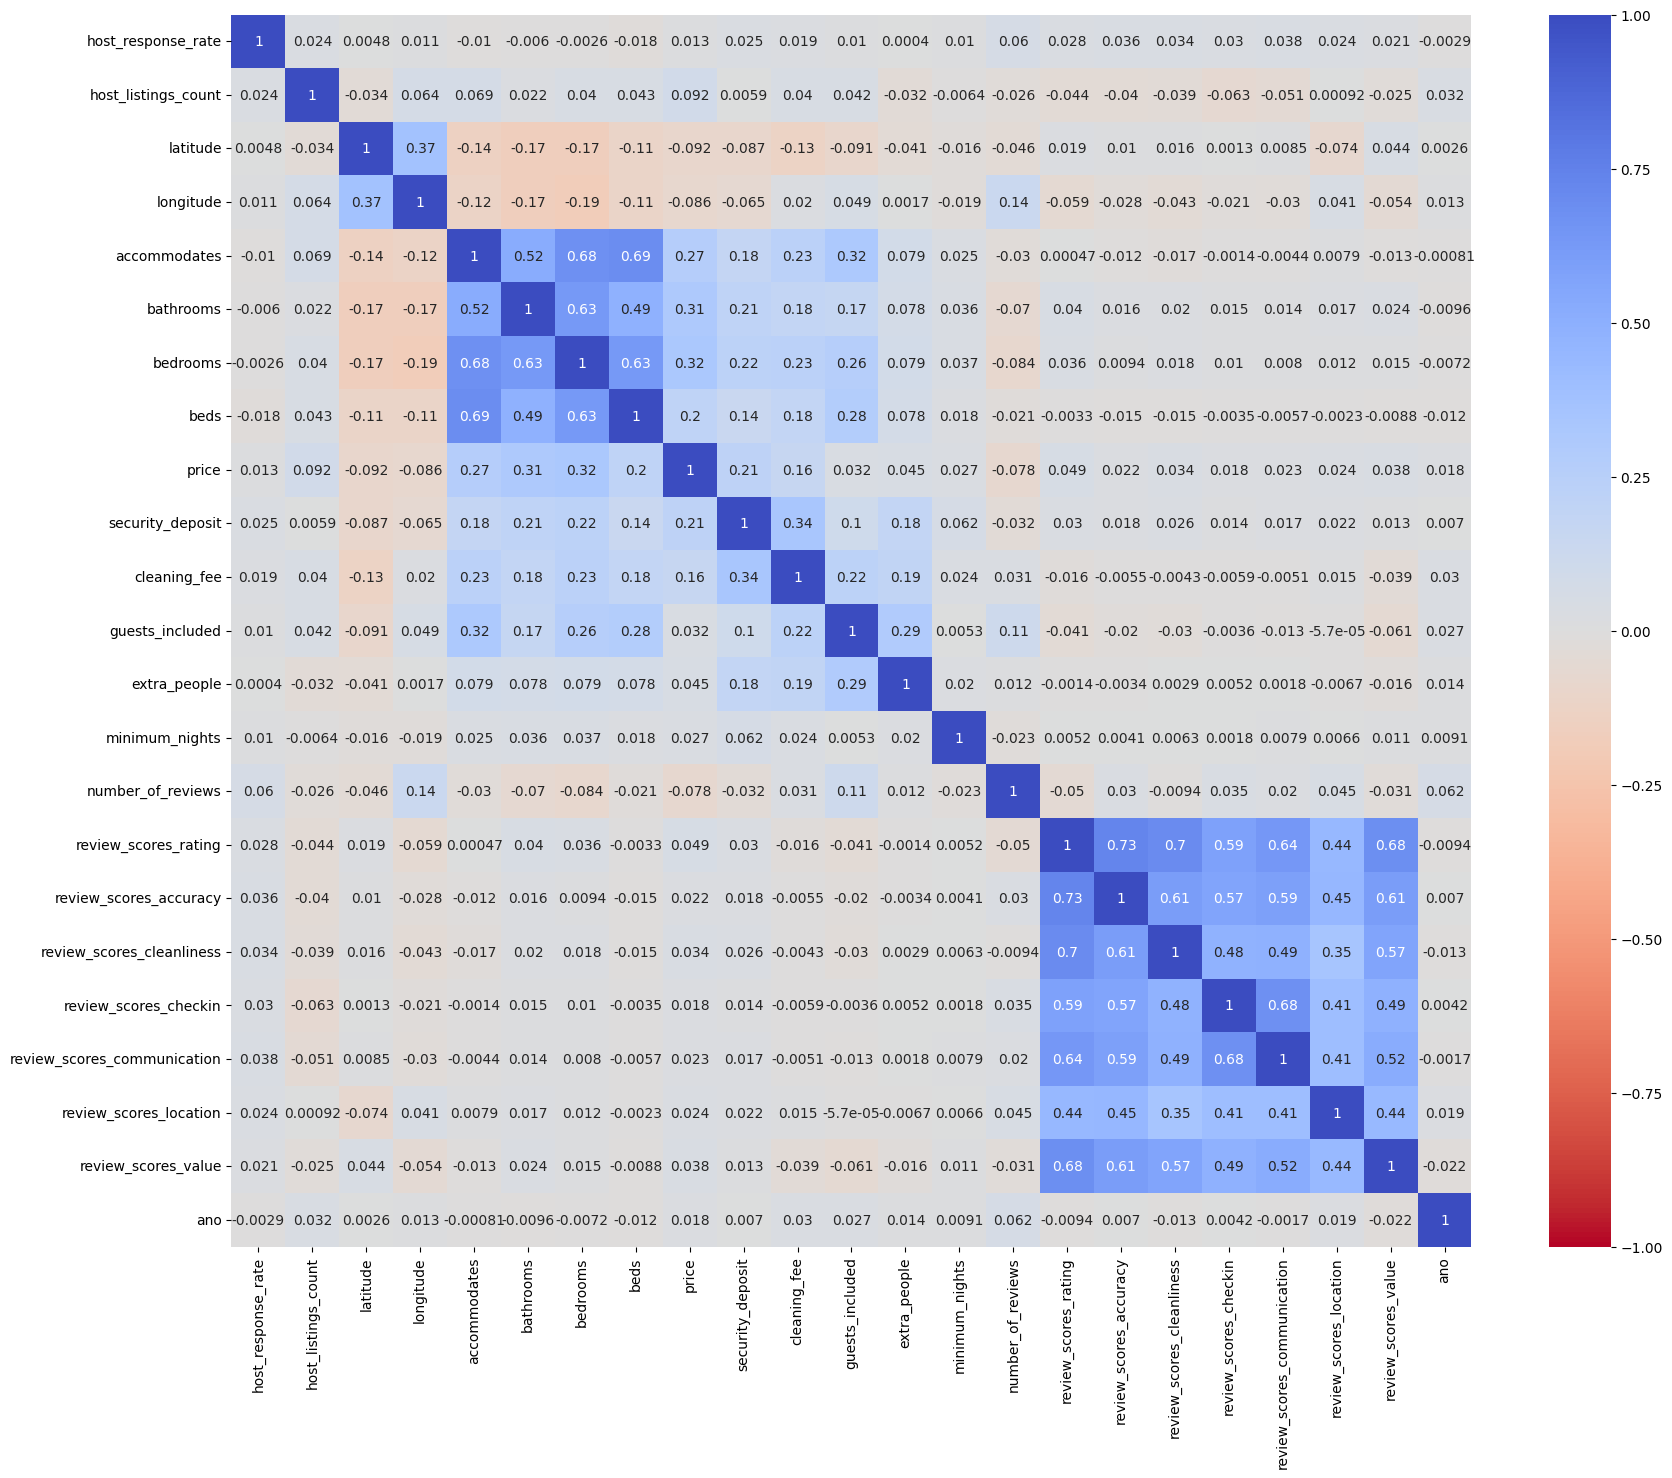

In [24]:
analise_numericas_df = analise_df.select_dtypes(include = "number")

plt.figure(figsize = (20,16))
sns.heatmap(analise_numericas_df.corr(), annot = True, cmap = "coolwarm_r" , vmin = -1)

plt.show()

Podemos observar que algumas das colunas de review possuem forte correlação em geral, com excessão da coluna de avaliação do local do imóvel. Por isso vamos manter em nosso modelo somente as colunas review_scores_rating e review_scores_location.

In [25]:
analise_df = analise_df.drop(columns = ["review_scores_accuracy","review_scores_cleanliness","review_scores_checkin","review_scores_communication","review_scores_value"])
display(analise_df.iloc[0])

host_response_rate                                                      100.0
host_is_superhost                                                           f
host_listings_count                                                       1.0
host_identity_verified                                                      t
neighbourhood_cleansed                                               Botafogo
latitude                                                           -22.946854
longitude                                                          -43.182737
property_type                                                       Apartment
room_type                                                     Entire home/apt
accommodates                                                                4
bathrooms                                                                 1.0
bedrooms                                                                  0.0
beds                                                            

Vamos separar as variáveis em categóricas, numéricas e alvo

In [26]:
df_categoricas = analise_df.select_dtypes(exclude = 'number')
df_numericas = analise_df.select_dtypes(include = 'number')
df_alvo = analise_df["price"]

Criação de funções para gerar gráficos e avaliar outliers

In [27]:
def limites(df , coluna):
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    amplitude = q3 - q1
    sup = q3 + 1.5*amplitude
    inf = q1 - 1.5*amplitude
    return inf , sup

def boxplot(df , coluna):
    fig , ax = plt.subplots(nrows = 1 , ncols = 2, figsize = (10 , 8))
    fig.set_size_inches(15 , 5)
    ax0 = sns.boxplot(y = df[coluna] , ax = ax[0])
    ax1 = sns.boxplot(y = df[coluna] , ax = ax[1])
    ax1.set_ylim(limites(df , coluna))

def distribuicao(df , coluna , hist , hue):
    fig, ax = plt.subplots(figsize = (15,5))
    if hist == True:
        ax1 = sns.histplot(x=coluna, data=df, fill=True, ax=ax, hue=hue)
        ax1.tick_params(axis = "x" , rotation = 90)
    else:
        ax1 = sns.kdeplot(x=coluna, data=df, fill=True, ax=ax, hue=hue)
        ax1.tick_params(axis = "x" , rotation = 90)
    #ax1 = sns.histplot(coluna , ax = ax)
    
def box_price(coluna):
    fig , ax = plt.subplots(nrows =1 , ncols =2, figsize= (10 , 6))
    ax0 = sns.boxplot(x = coluna , y = 'price' , data = analise_df, ax = ax[0])
    ax0.tick_params(axis = 'x' , rotation = 90)
    ax1 = sns.boxplot(x = coluna , y = 'price' , data = analise_df , ax = ax[1])
    ax1.tick_params(axis = 'x' , rotation = 90)
    ax1.set_ylim(limites(df_alvo))

def excluir_outliers(df , coluna):
    limite = limites(df , coluna)
    inicial = df.shape[0]
    df_filtrado = df[(df[coluna] > limite[0]) & (df[coluna] < limite[1])]
    final = df_filtrado.shape[0]
    linhas_excluidas = inicial - final
    return df_filtrado , linhas_excluidas

def bar(df , coluna):
    fig, ax = plt.subplots(figsize = (15,5))
    ax = sns.barplot(x= df[coluna].value_counts().index, y = df[coluna].value_counts())
    ax.tick_params(axis = "x" , rotation = 90)

Análise da variável alvo isolada:

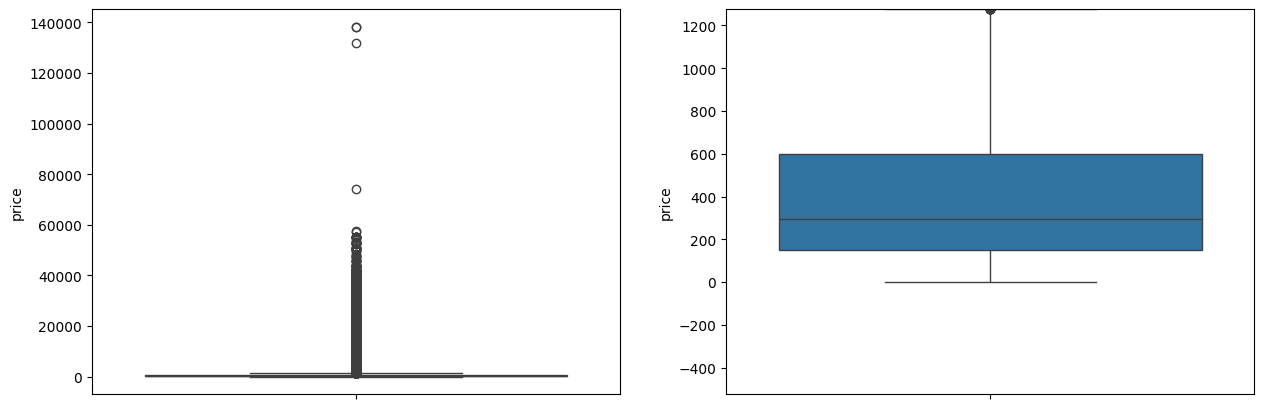

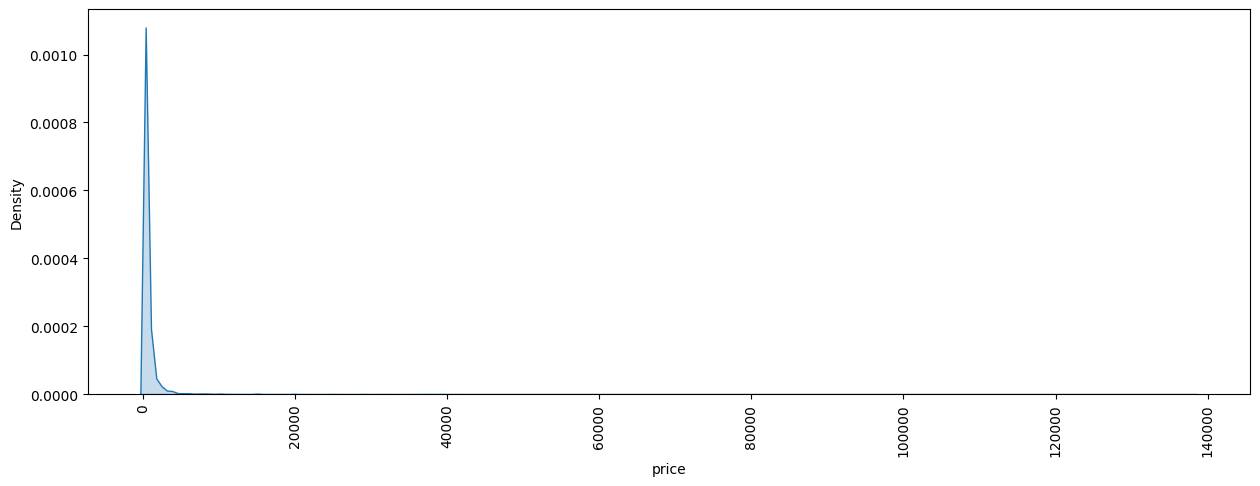

In [28]:
boxplot(analise_df , 'price')
distribuicao(df =analise_df, coluna = "price", hist = False , hue = None)

In [29]:
print(analise_df['price'].quantile(0.75))

analise_df.loc[analise_df['price'] > 1000].shape[0]

601.0


122024

Como podemos ver, há muitos outliers nessa variável , porém, 75% dos valores possui valor da diária menor que 601, e um valor de mais de 1000 em mais de 10% dos imóveis, o que mostra que pode haver uma boa quantidade de imóveis de luxo

In [30]:
# análise variáveis categóricas:

df_categoricas["amenities"] = df_categoricas['amenities'].str.replace({r"{" : r"" , r"}" : r"" , r"," : r" "})
print(df_categoricas["amenities"].value_counts())

amenities
                                                                                                                                                                                                                                                                   9850
TV "Cable TV" Internet Wifi "Air conditioning" Kitchen Doorman Elevator "Buzzer/wireless intercom" Washer                                                                                                                                                           450
"Family/kid friendly"                                                                                                                                                                                                                                               408
TV "Cable TV" Internet Wifi "Air conditioning" Kitchen Doorman Elevator "Buzzer/wireless intercom" "Family/kid friendly" Washer                                                                       

Tomando como base a a descrição acima da variável amenities, decidimos excluir ela, pois é uma descrição breve do que tem no imóvel e muitos atributos são repetidos entre as linhas.

In [31]:
analise_df = analise_df.drop(columns = 'amenities')
df_categoricas = df_categoricas.drop(columns = 'amenities')


neighbourhood_cleansed
Copacabana                  223581
Barra da Tijuca             101458
Ipanema                      75542
Jacarepaguá                  52005
Recreio dos Bandeirantes     45172
                             ...  
Jardim América                   9
Costa Barros                     6
Turiaçú                          2
Zumbi                            2
Jacarezinho                      2
Name: count, Length: 159, dtype: int64

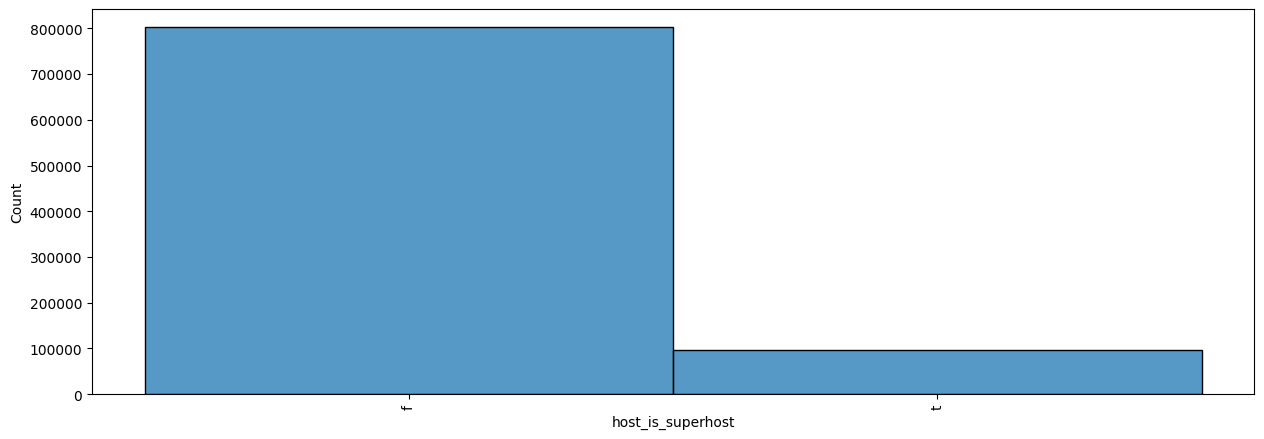

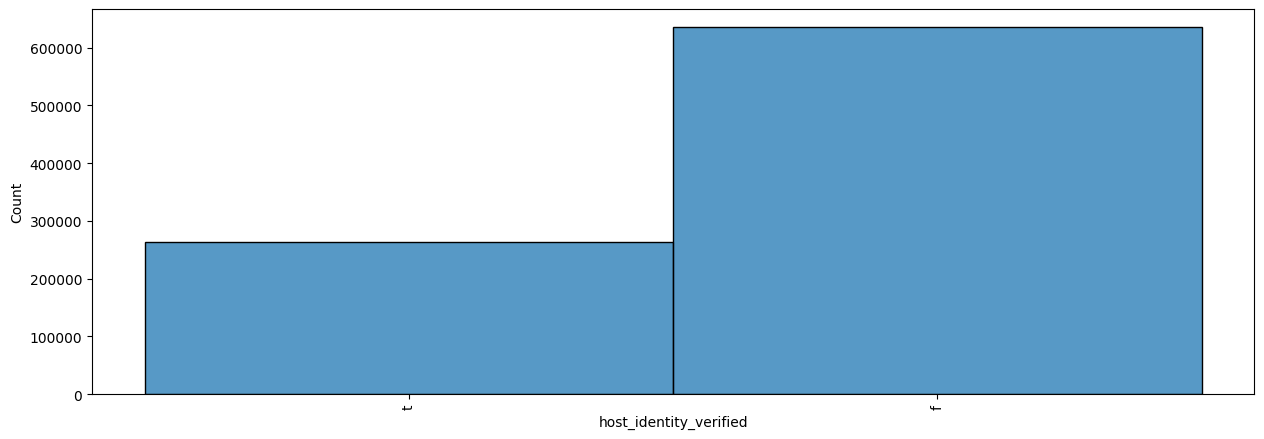

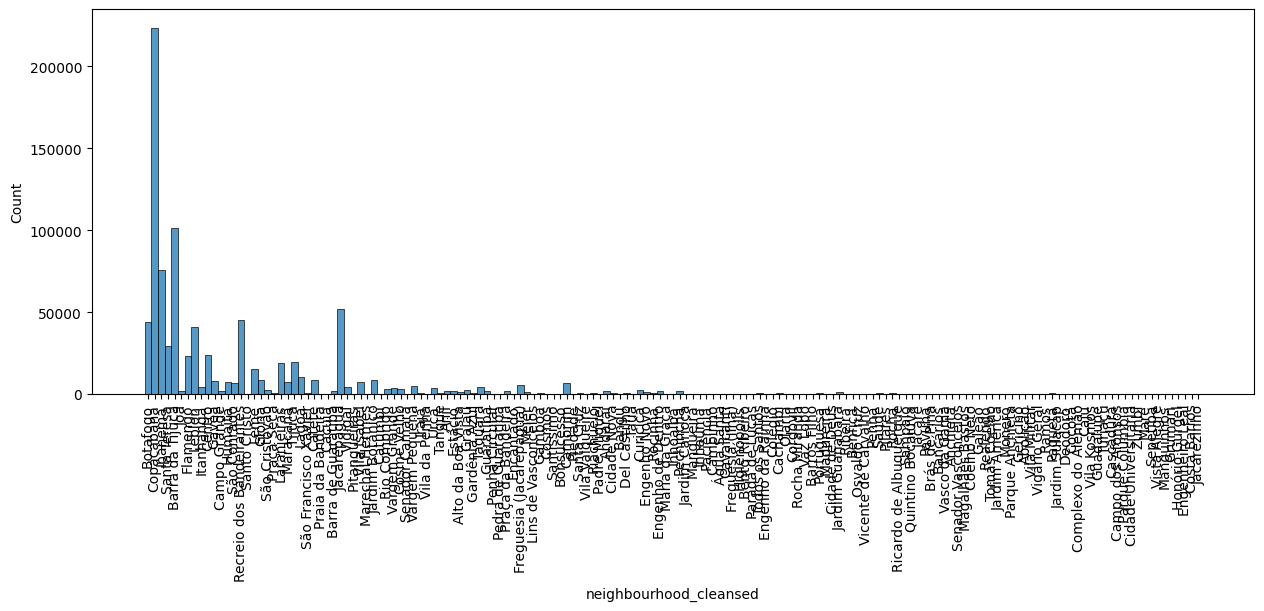

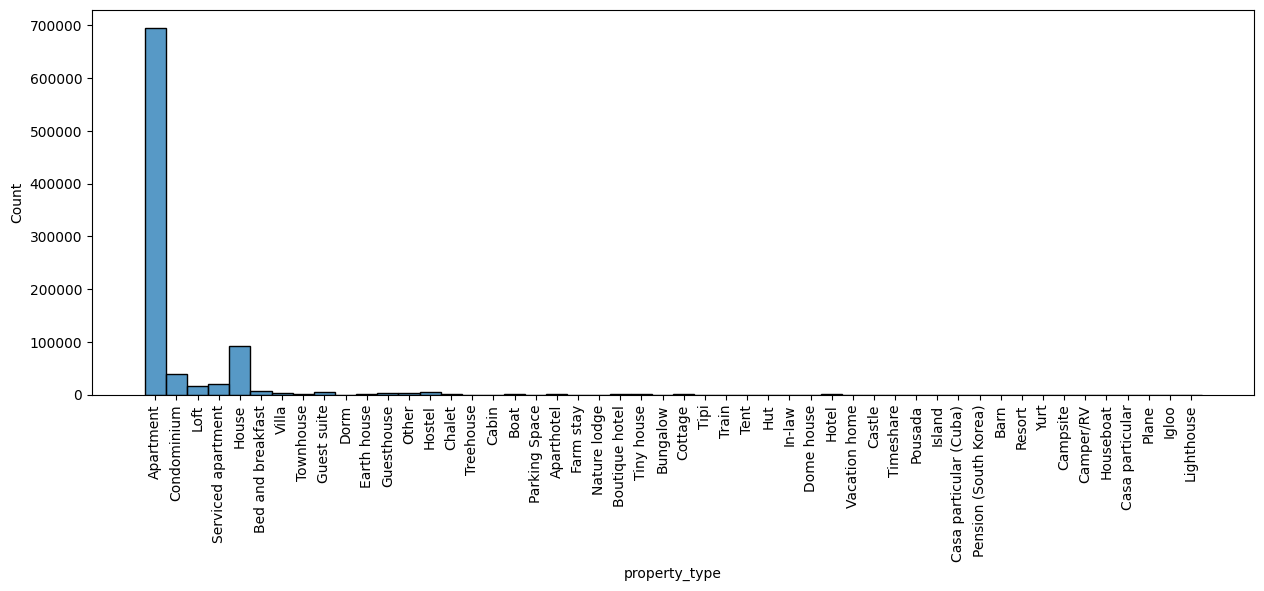

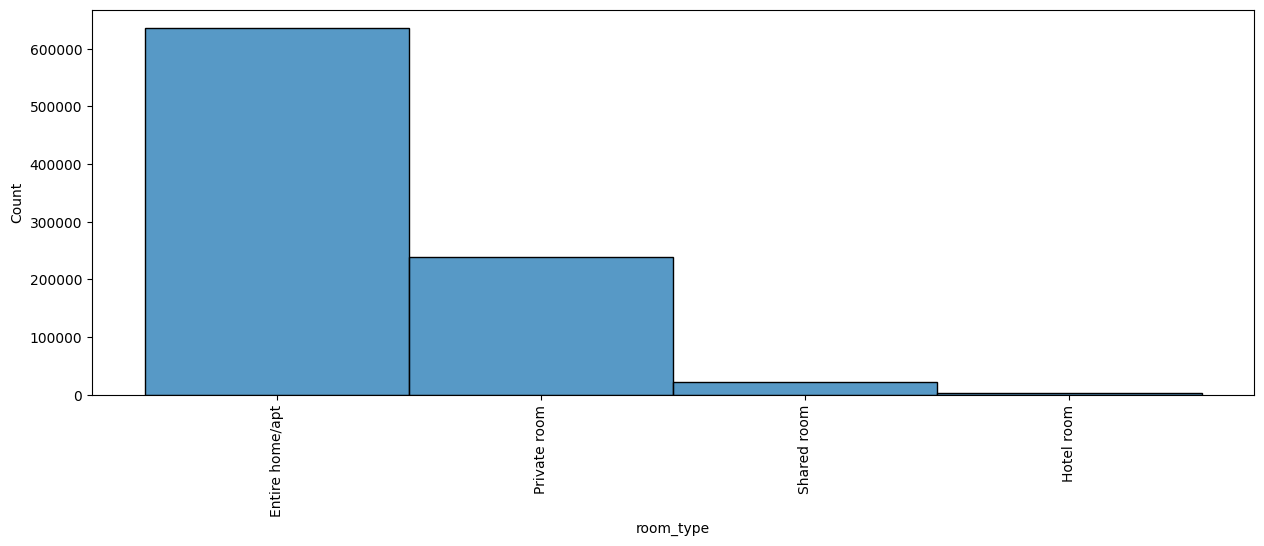

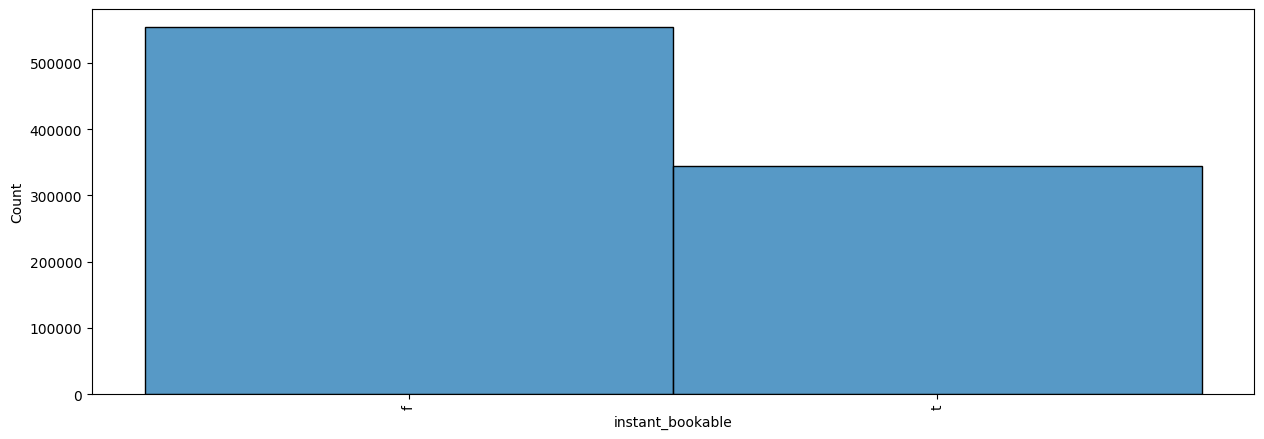

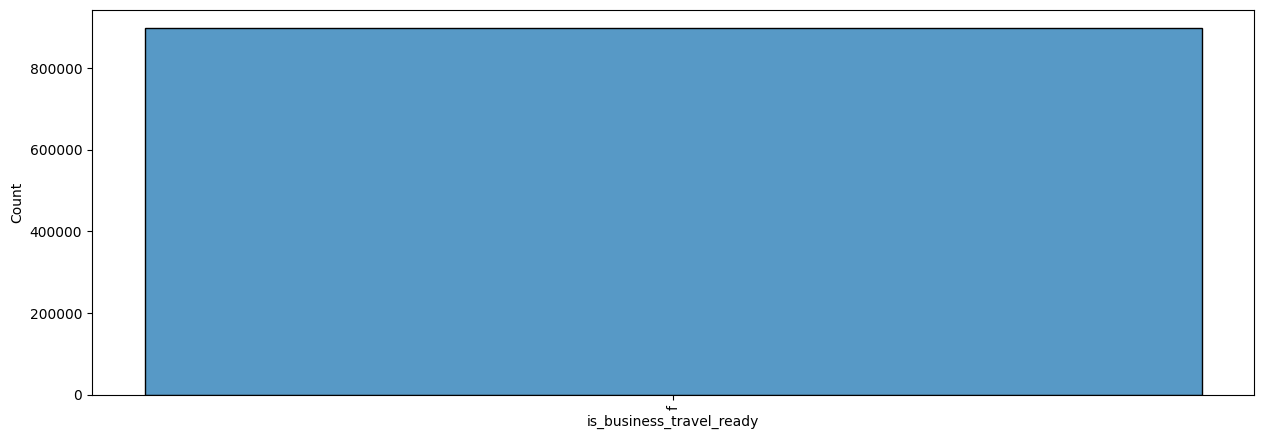

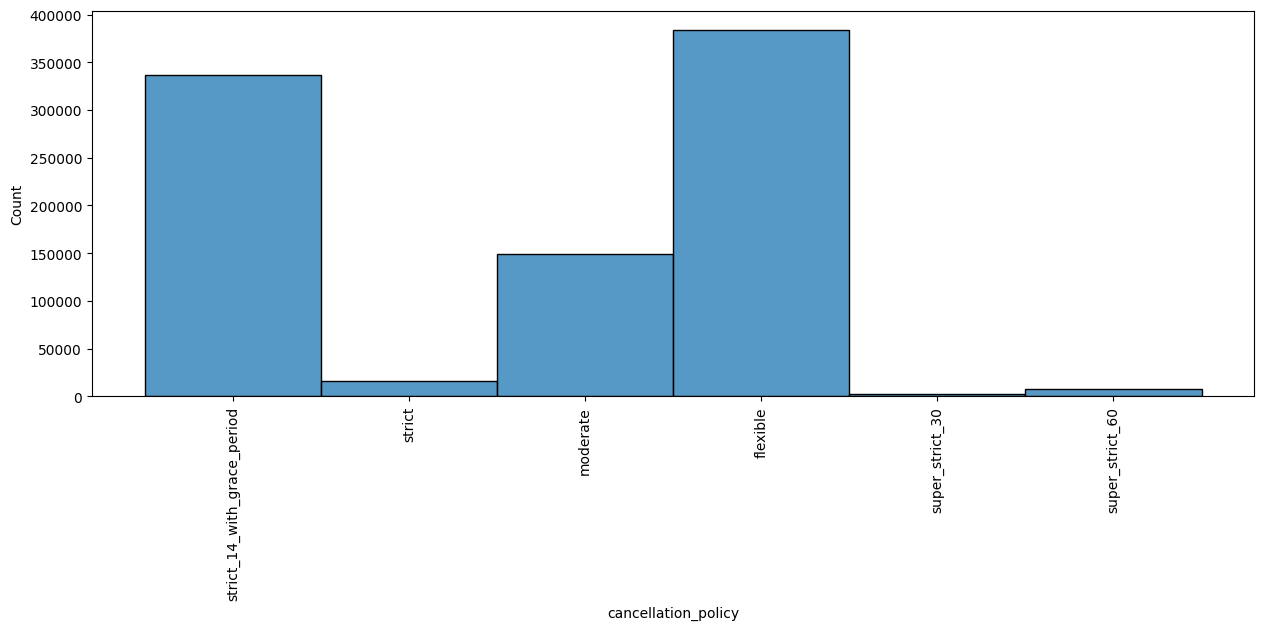

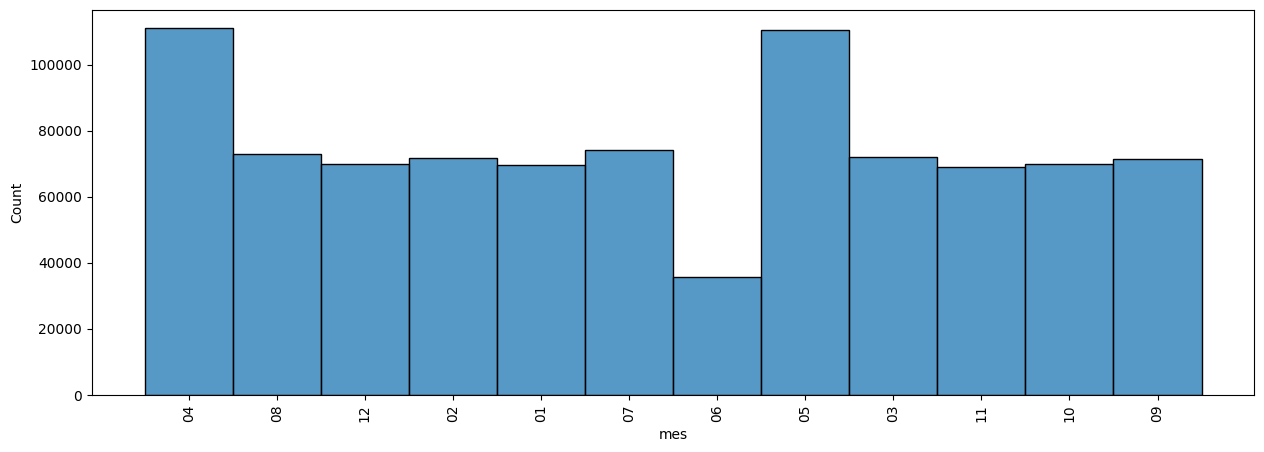

In [32]:
colunas = df_categoricas.columns.tolist()

for coluna in colunas:
    distribuicao(df = df_categoricas , coluna = coluna , hist = True , hue = None)

display(df_categoricas['neighbourhood_cleansed'].value_counts())


Podemos ver que a maioria dos imóveis são do tipo apartamentos

In [33]:
def media_agrupada(df , coluna):
    df = df[[coluna , 'price']].groupby(coluna).mean().sort_values(by = 'price', ascending = False)
    return df

In [34]:
bairros = media_agrupada(analise_df , 'neighbourhood_cleansed')
property = media_agrupada(analise_df , 'property_type')
cancellation = media_agrupada(analise_df , 'cancellation_policy')
room = media_agrupada(analise_df , 'room_type')
indentity = media_agrupada(analise_df , 'host_identity_verified')
bookable = media_agrupada(analise_df , 'instant_bookable')

display(bairros)
display(property)
display(cancellation)
display(room)
display(indentity)
display(bookable)

,price
neighbourhood_cleansed,
Ramos,3355.089286
Joá,3319.329155
Bangu,2724.895299
Padre Miguel,2018.202247
Campinho,1834.979592
...,...
Vila Kosmos,81.050000
Honório Gurgel,79.193548
Colégio,75.023256


,price
property_type,
Houseboat,19302.612903
Boat,5665.501852
Farm stay,3633.263889
Villa,2802.008345
Vacation home,1716.393939
Hotel,1143.088215
Boutique hotel,1101.674713
Cabin,1098.326599
House,1059.335347


,price
cancellation_policy,
super_strict_60,1581.278727
super_strict_30,1128.380630
flexible,745.762127
strict_14_with_grace_period,609.452707
strict,539.315273
moderate,433.897945


,price
room_type,
Entire home/apt,802.466609
Hotel room,739.697645
Private room,270.947292
Shared room,235.827692


,price
host_identity_verified,
f,677.895869
t,575.419946


,price
instant_bookable,
f,714.062150
t,541.486496


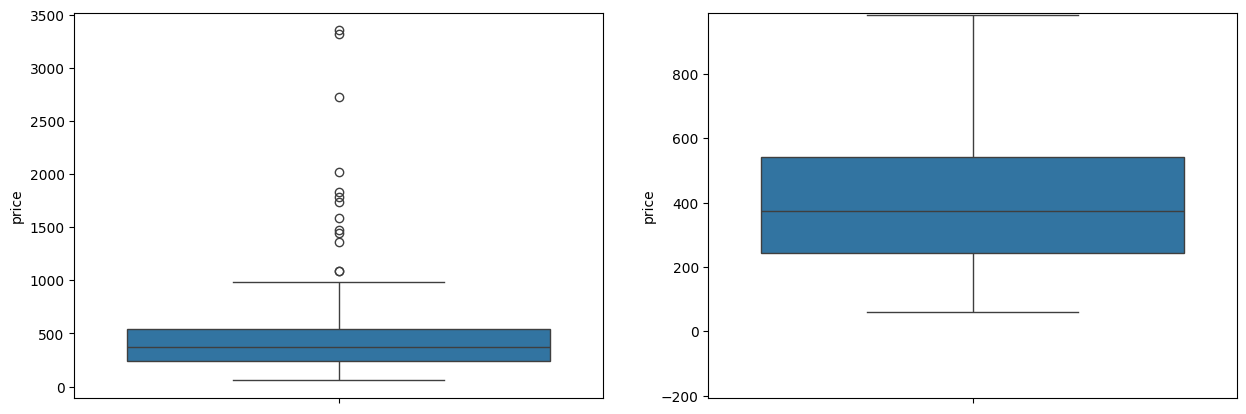

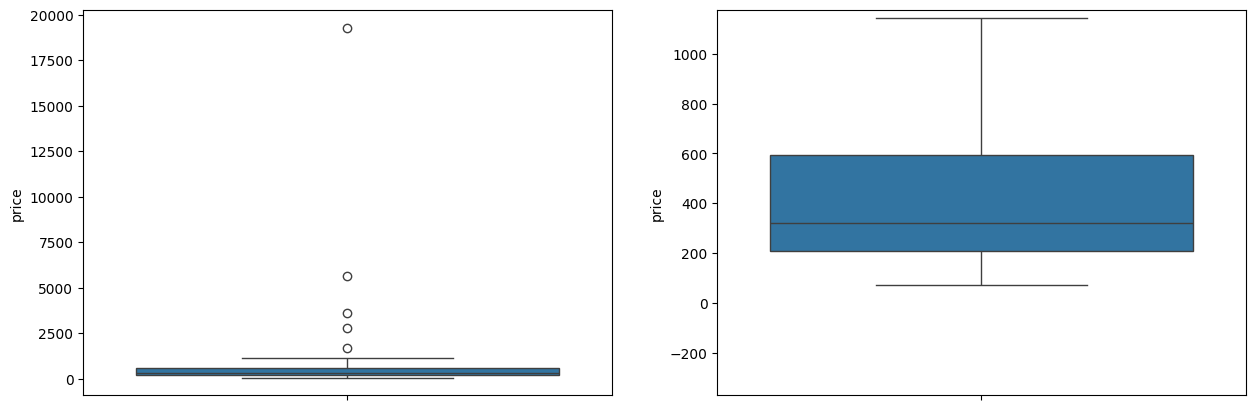

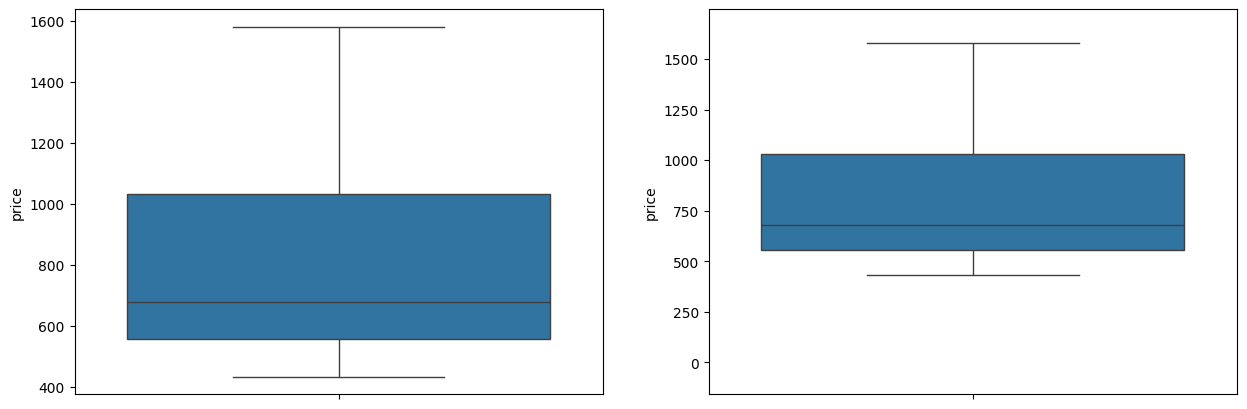

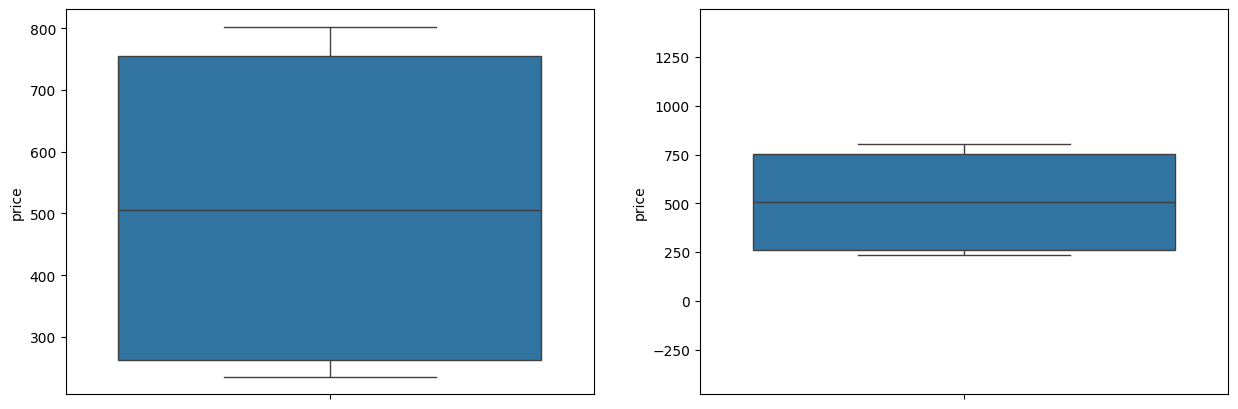

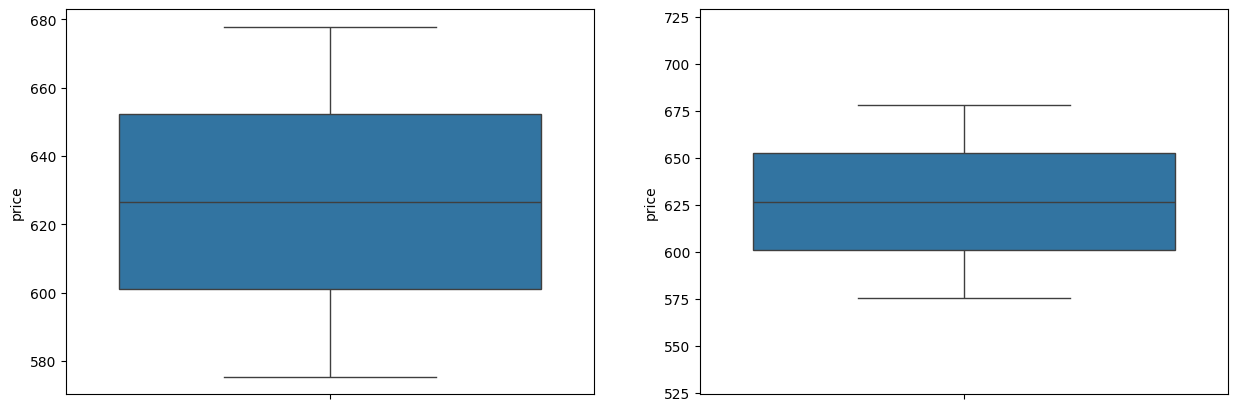

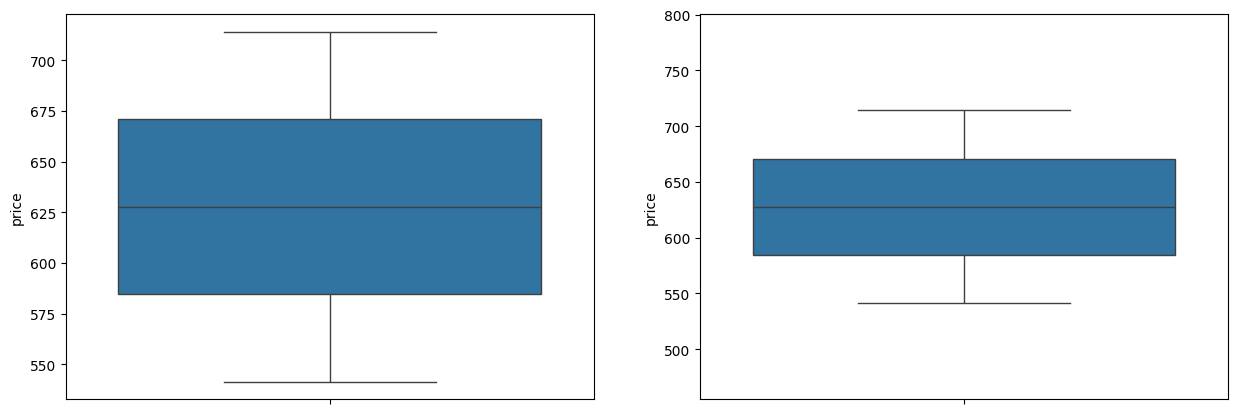

In [35]:
boxplot(bairros , 'price')
boxplot(property , 'price')
boxplot(cancellation ,'price')
boxplot(room ,'price')
boxplot(indentity , 'price')
boxplot(bookable , 'price')

Podemos ver pelos gráficos acima que a média dos preços bairro onde está situada a propriedade é uma variável que muda bastante o preço do Airbnb. Podemos ver que há uma quantidade razoável de outliers. Sobre o tipo de propriedade , alguns tipos de propriedades tem valores muito acima, especialmente Houseboat que possui média próxima a 20000, o que pode ser algum tipo de imóvel de luxo. Sobre as variáveis room_type e cancellation_policy, nenhuma delas apresentou valores fora do intervalo interquartílico. Isso pode mostra que talvez essas variáveis não tenham muita influência no preço final. Outra possível causa é que essas variáveis não possuem muitas categorias.

Vamos analisar agora as variáveis numéricas e como elas fazem efeito sobre o preço do Airbnb. 

C:\Users\vitor\AppData\Local\Temp\ipykernel_5124\896269565.py:14: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax1.set_ylim(limites(df , coluna))
C:\Users\vitor\AppData\Local\Temp\ipykernel_5124\896269565.py:14: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax1.set_ylim(limites(df , coluna))


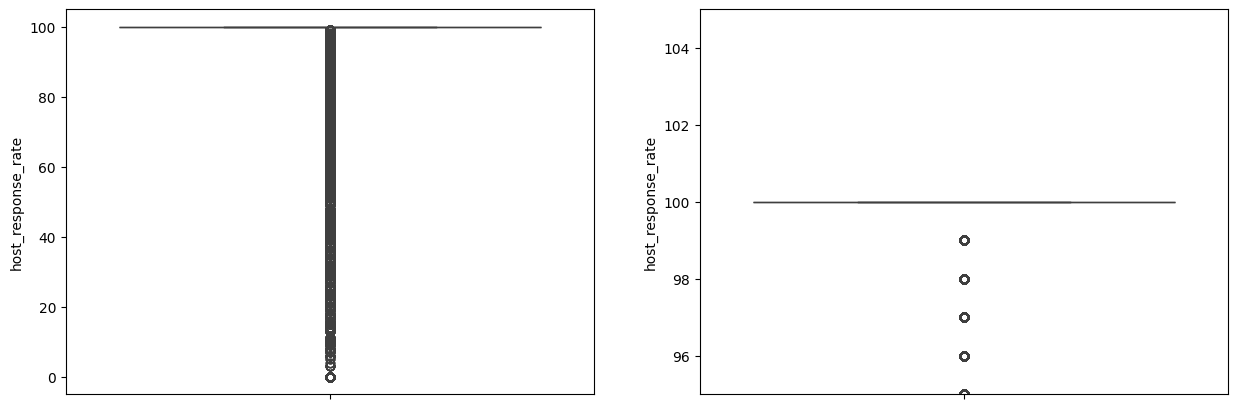

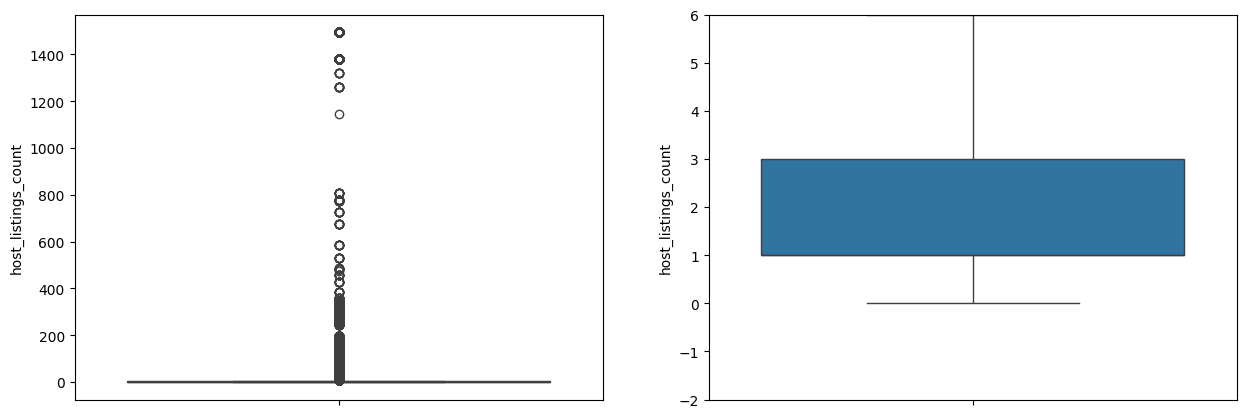

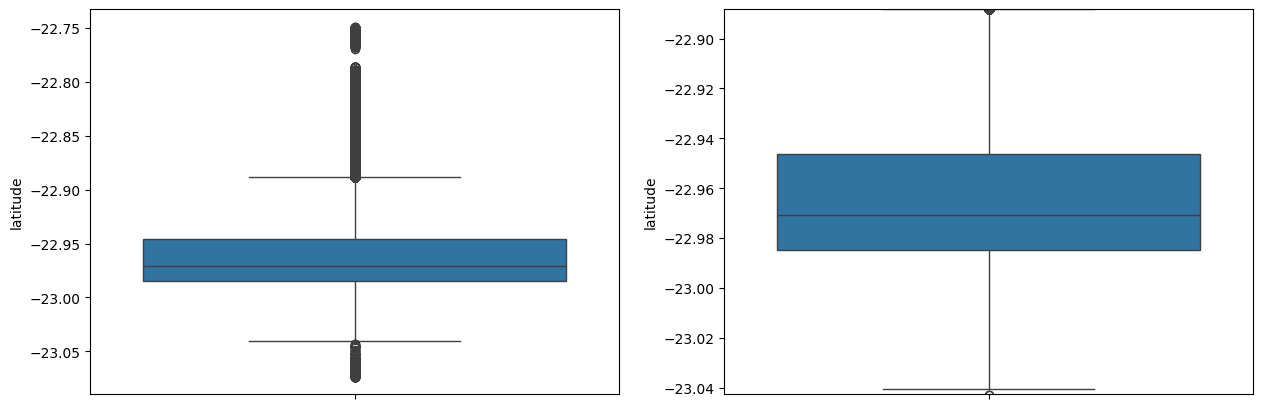

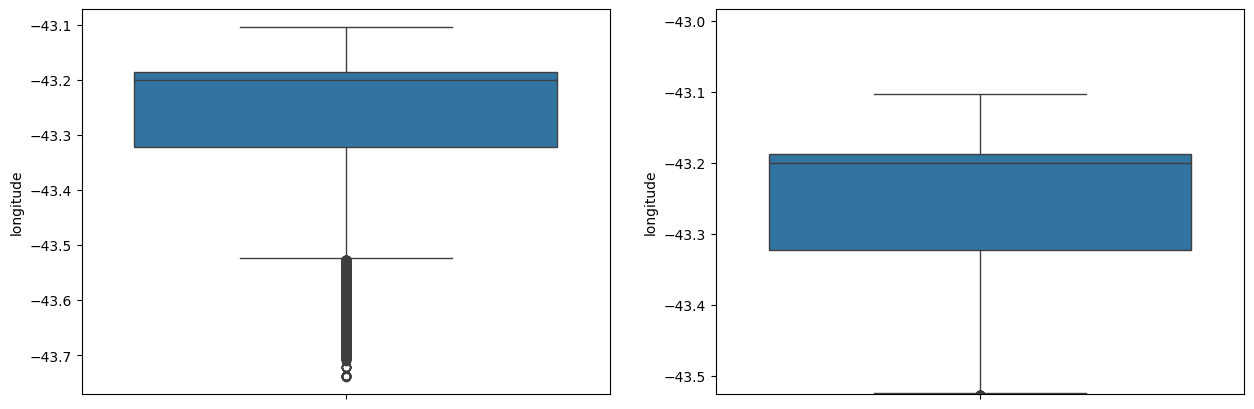

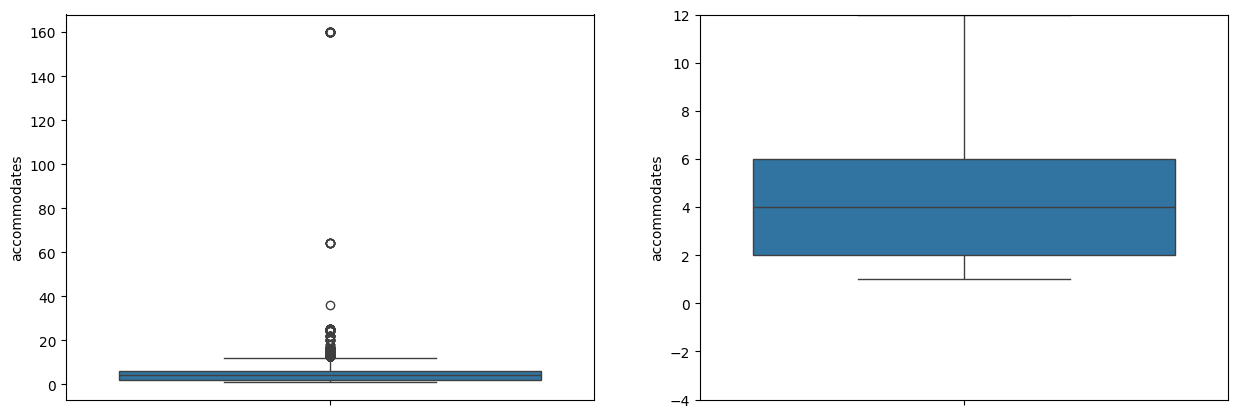

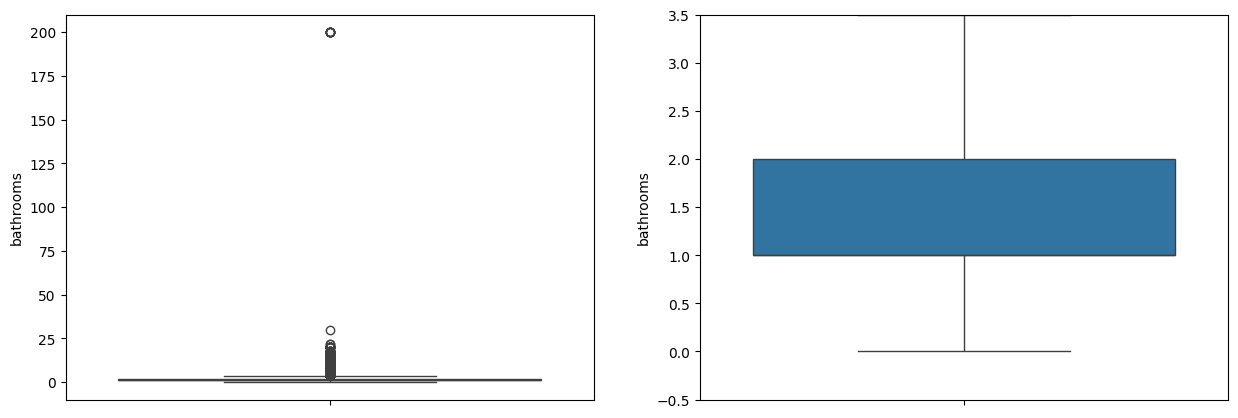

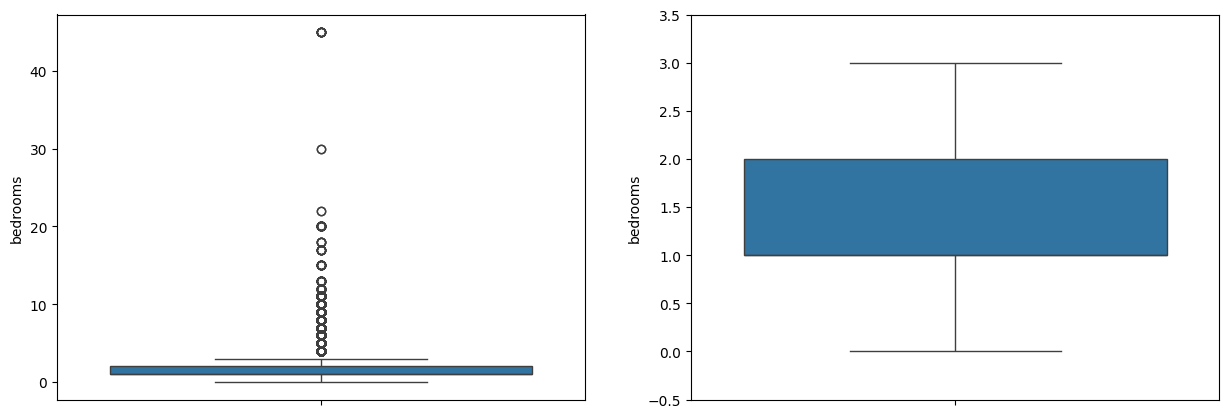

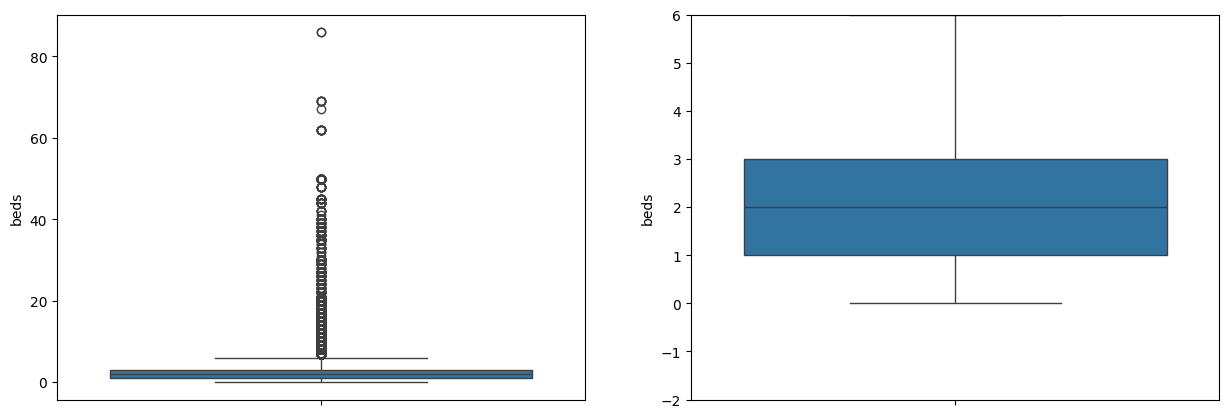

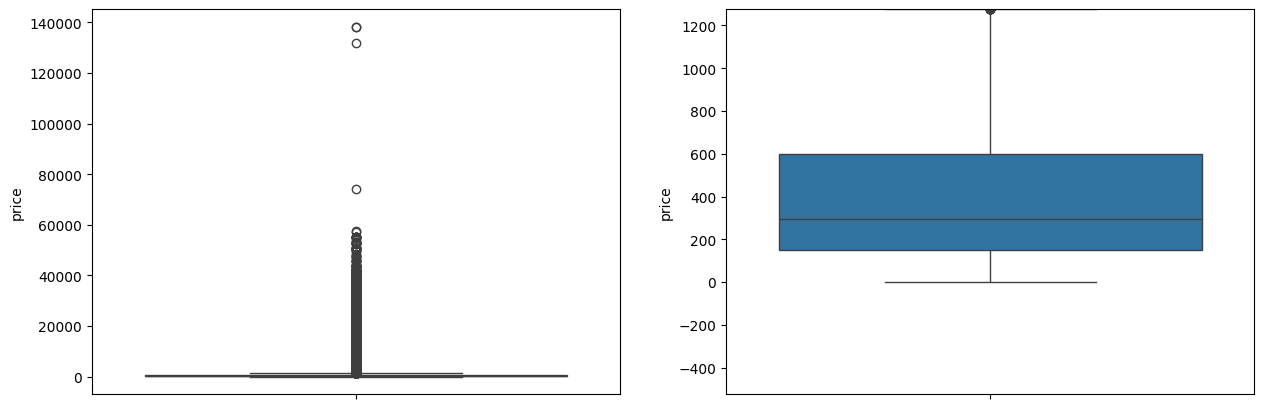

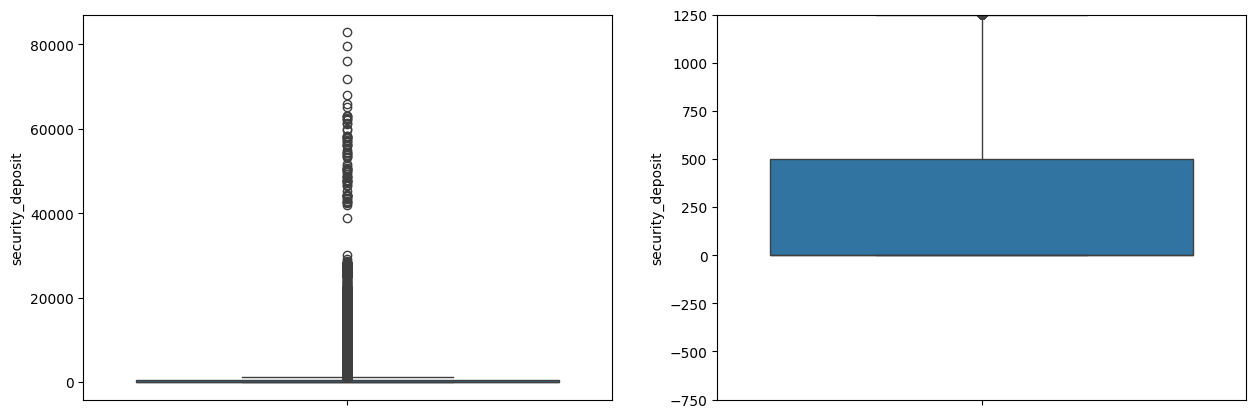

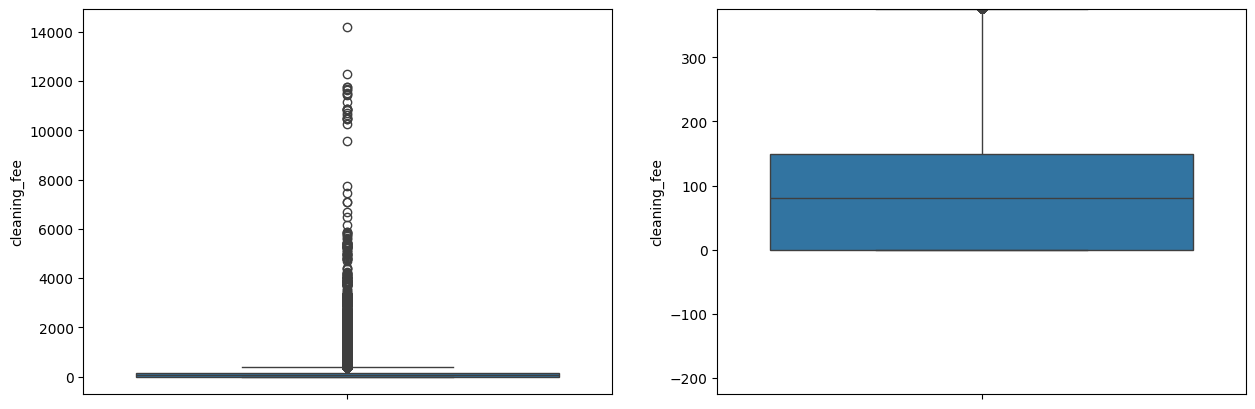

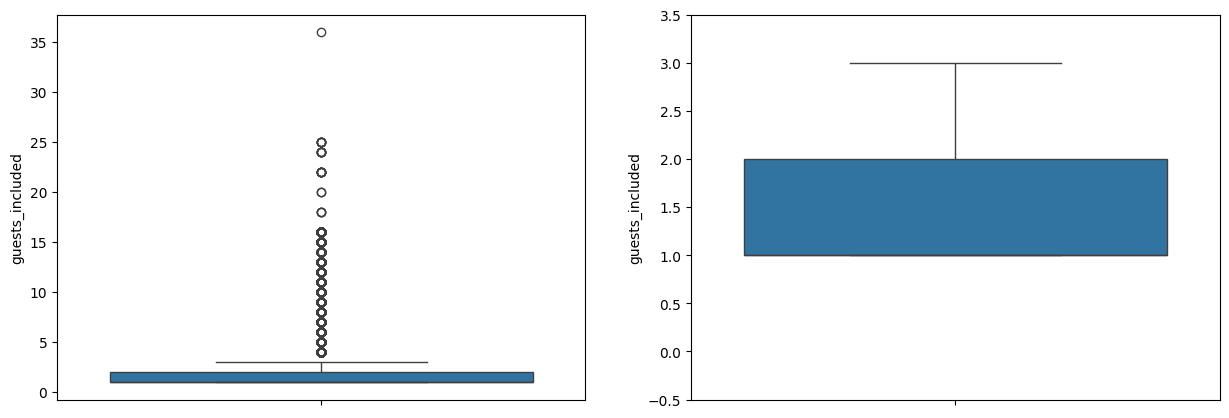

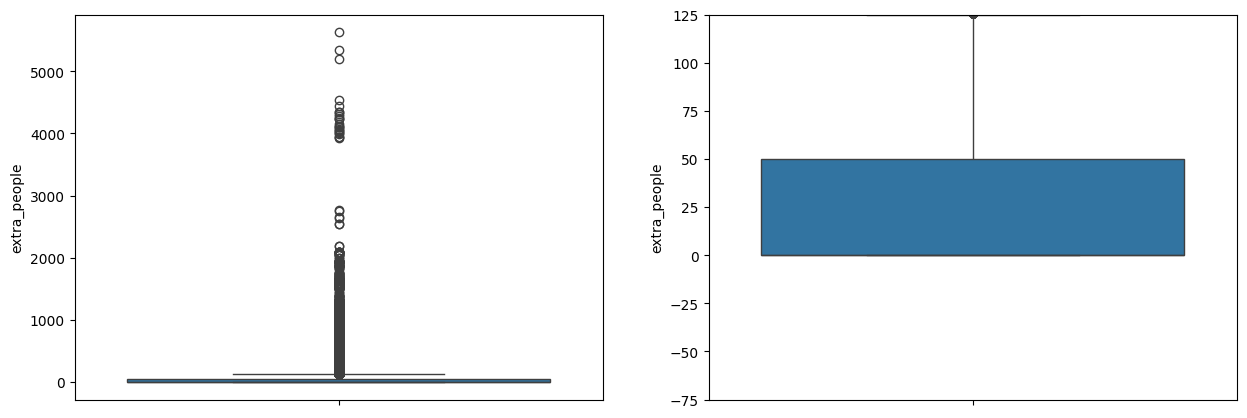

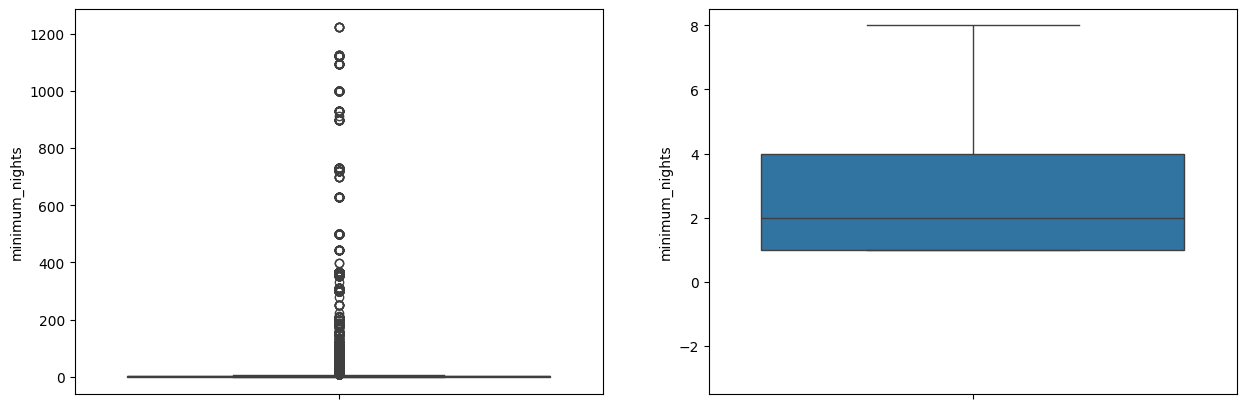

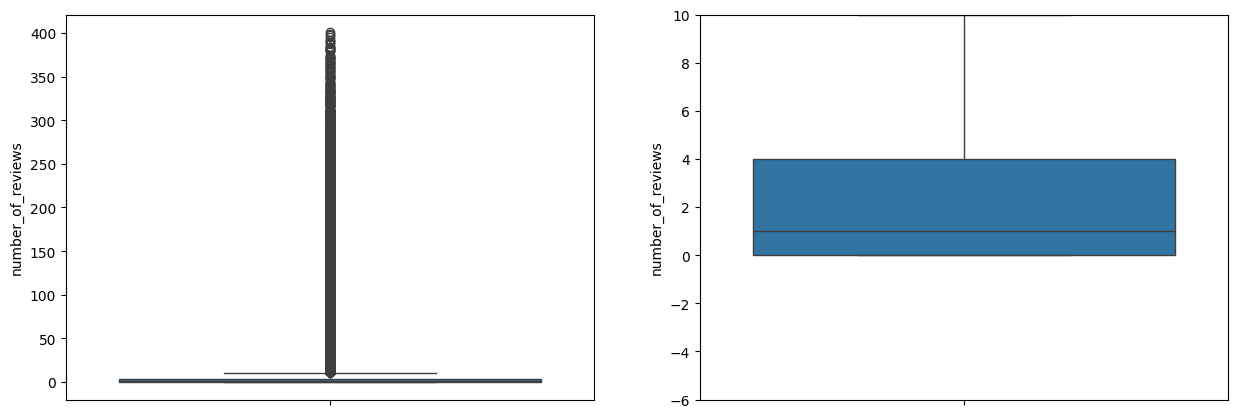

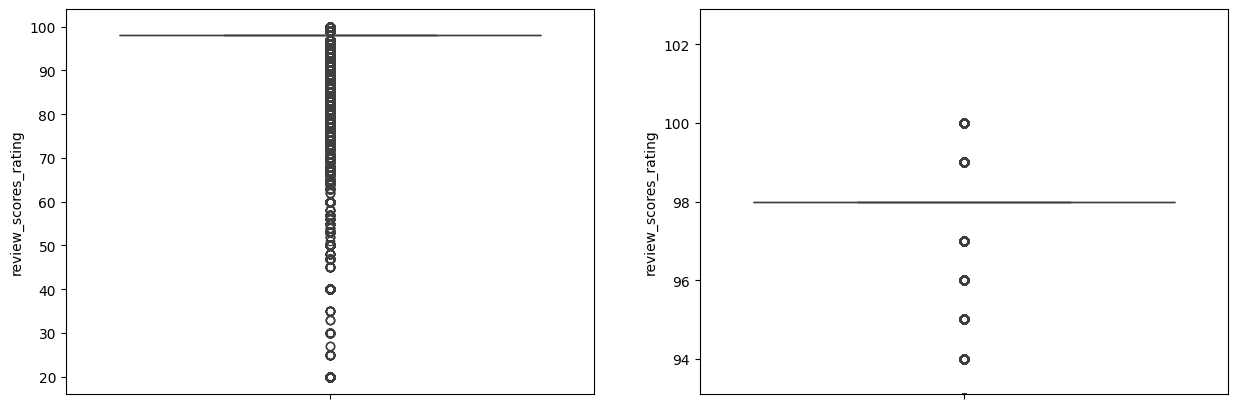

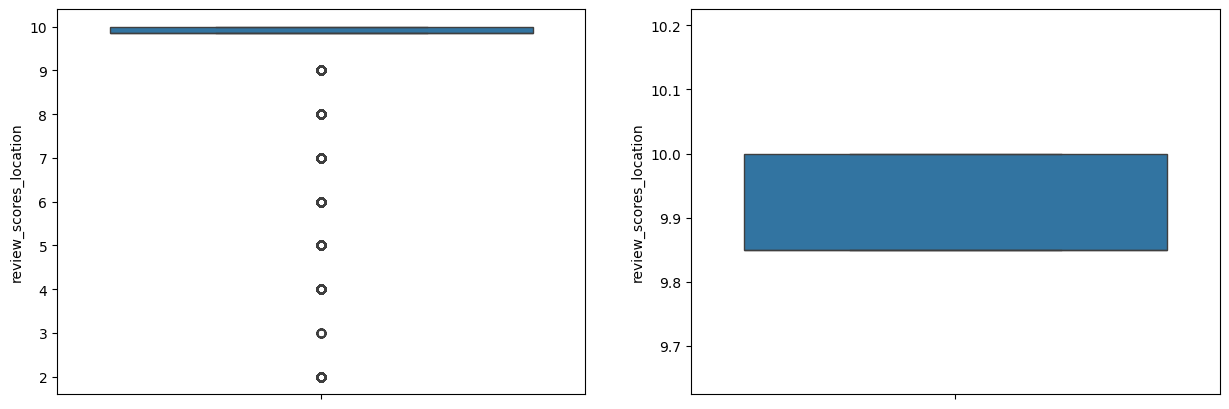

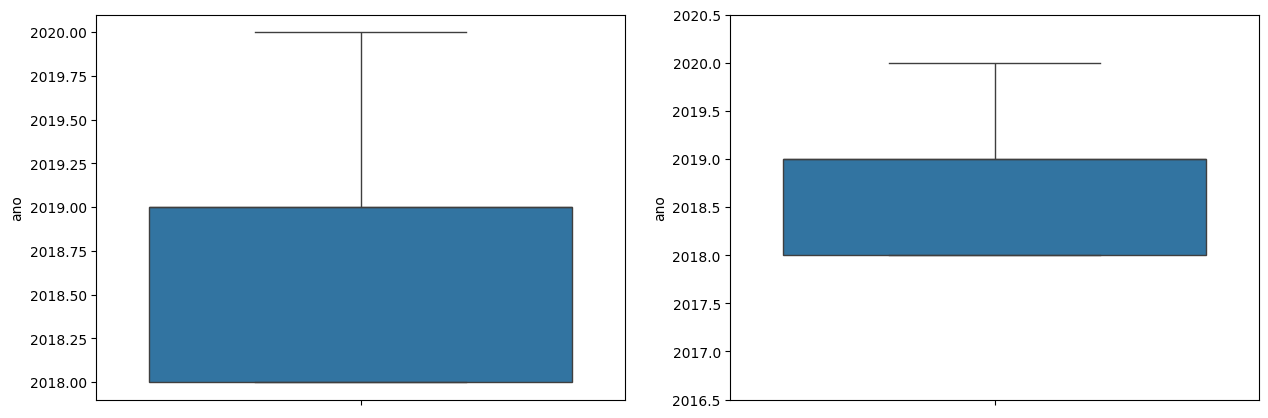

In [36]:
for coluna in df_numericas.columns.tolist():
    boxplot(df_numericas , coluna)

Analisando host response hate:

In [37]:
display(df_numericas['host_response_rate'].value_counts())

host_response_rate
100.0    695720
0.0       31658
90.0      22253
80.0      14798
50.0      14444
          ...  
16.0         11
3.0          10
7.0          10
5.0           4
4.0           3
Name: count, Length: 98, dtype: int64

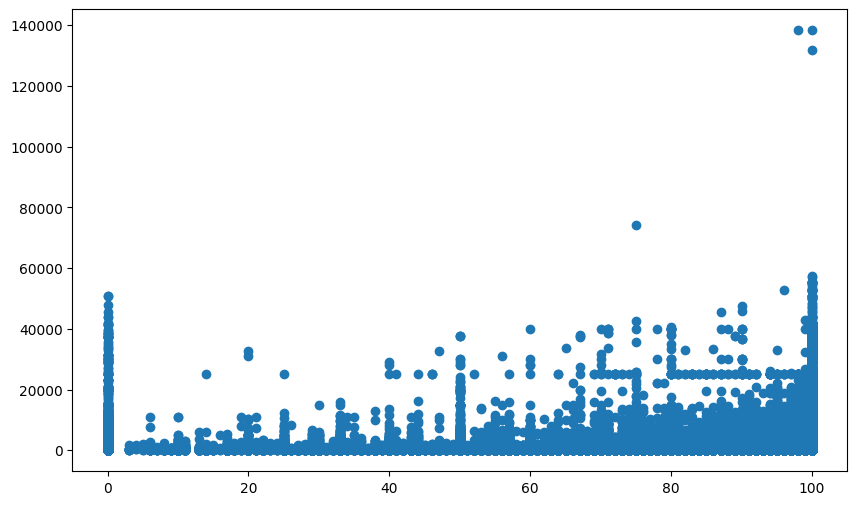

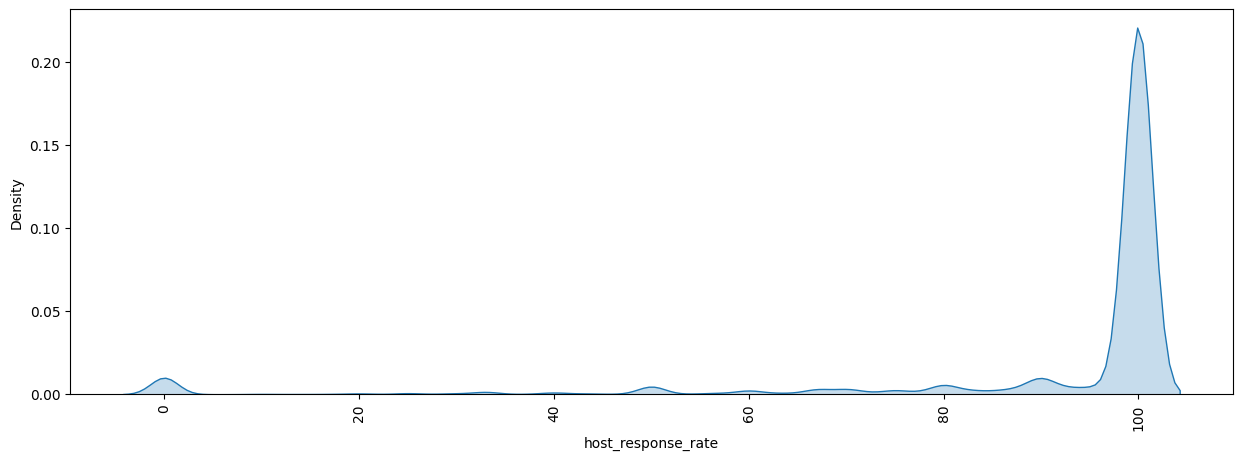

In [38]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax = plt.scatter(x = df_numericas['host_response_rate'] , y = df_numericas['price'])

plt.show()

distribuicao(df_numericas , 'host_response_rate' , hist = False , hue = None)

Podemos obsevar que a grande maioria dos host possui taxa de resposta de 100%. Pelo scatter plot, a variável de preço e resposta do host não parece ter efeito forte na variável alvo, além que a maioria dos hosts sempre responde. Com isso, podemos considerar excluir essa variável para nossa seleção de modelos. 

In [39]:
analise_df = analise_df.drop(columns = "host_response_rate")

Análise da variável host_listing_counts

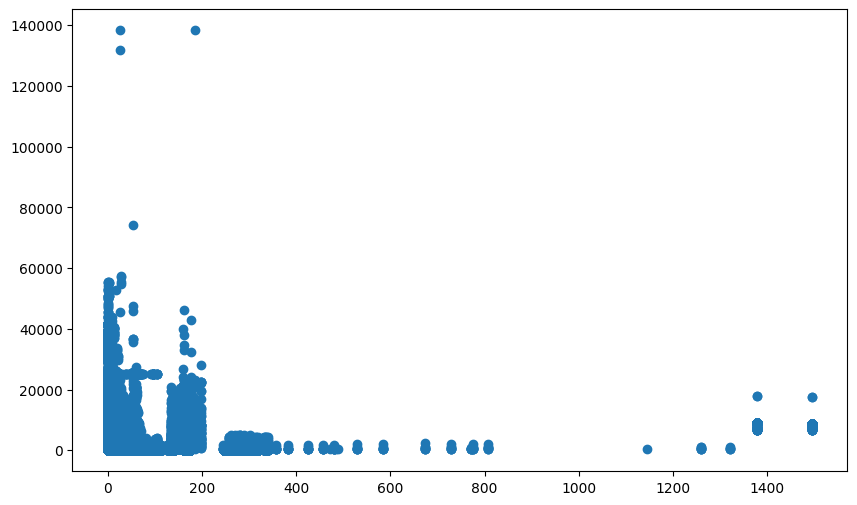

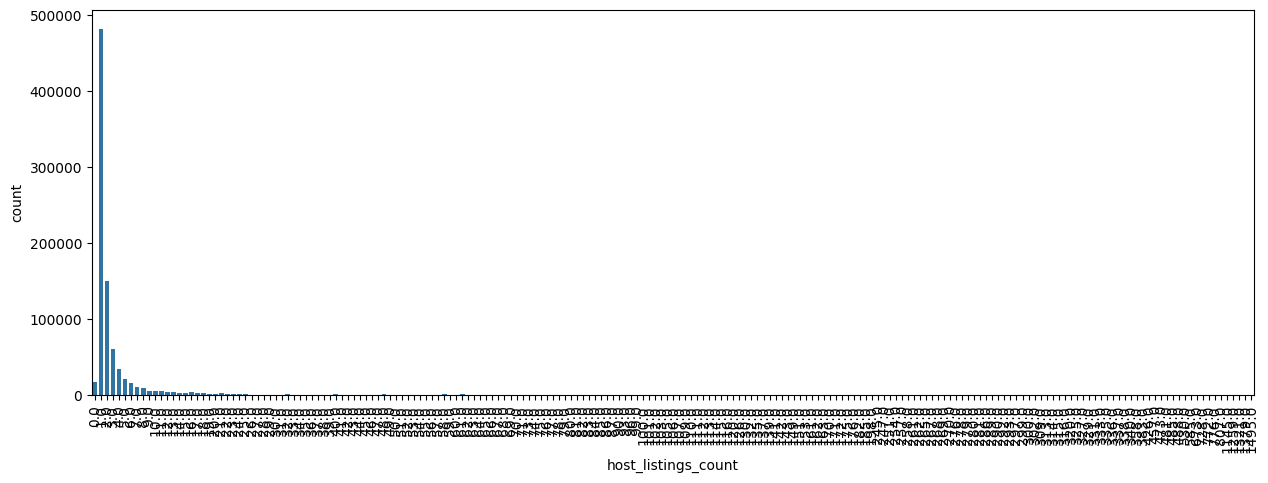

In [40]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['host_listings_count'] , y = df_numericas['price'])


plt.show()

bar(df_numericas , 'host_listings_count')

Podemos ver pelo gráfico scatterplot que a maior parte dos imóveis mais caros, está concentrado nos host com mais de 20 imóveis. Esse tipo de host pode ser imobiliárias ou de profissionais da área. 

### accomodates

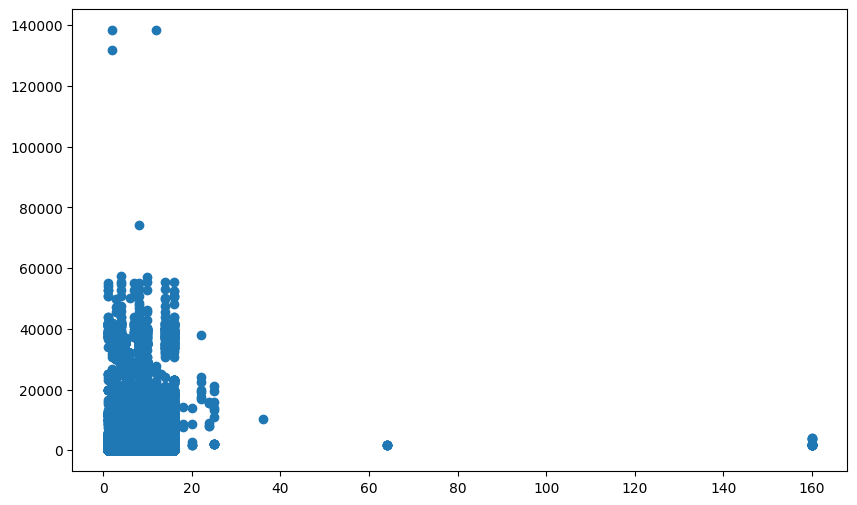

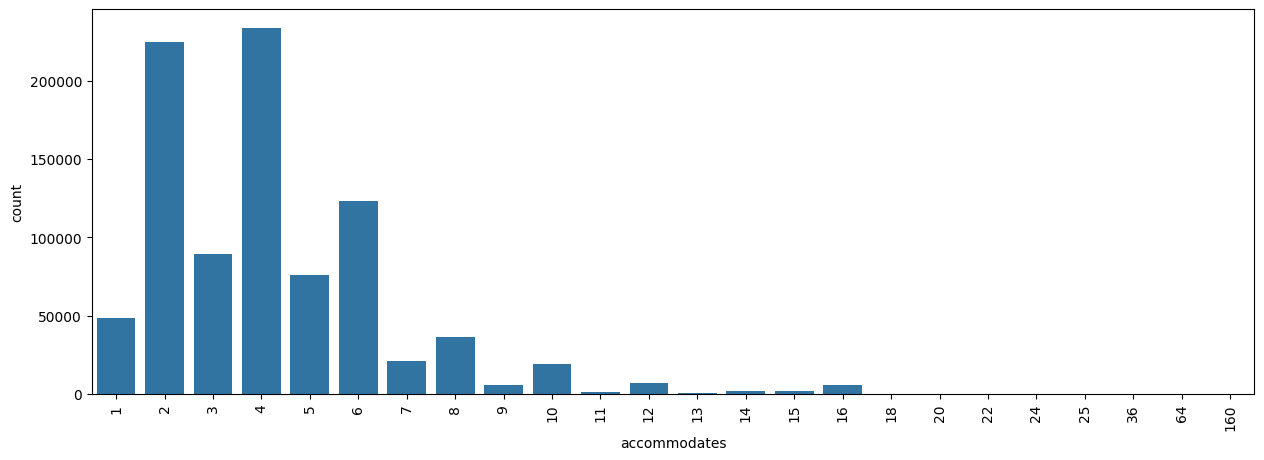

In [41]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['accommodates'] , y = df_numericas['price'])

plt.show()

bar(df_numericas , 'accommodates')

In [42]:
novo , qtd = excluir_outliers(df_numericas , "accommodates")
print(qtd)

18077


Avaliando essa variável , vemos que o número de outliers não é muito significativo. Além disso, o scatterplot mostra que não parece haver grande efeito da variável sobre o alvo, por isso vamos excluir os outliers dessa coluna.

In [43]:
analise_df , qtd = excluir_outliers(analise_df , "accommodates")
display(analise_df)

,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,extra_people,minimum_nights,number_of_reviews,review_scores_rating,review_scores_location,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano
0,f,1.0,t,Botafogo,-22.946854,-43.182737,Apartment,Entire home/apt,4,1.0,...,34.0,60,38,91.0,9.00,f,f,strict_14_with_grace_period,04,2018.0
1,t,2.0,f,Copacabana,-22.965919,-43.178962,Condominium,Entire home/apt,5,1.0,...,51.0,4,205,93.0,9.00,t,f,strict,04,2018.0
2,f,1.0,t,Ipanema,-22.985698,-43.201935,Apartment,Entire home/apt,2,1.0,...,215.0,3,85,95.0,10.00,f,f,strict,04,2018.0
3,f,3.0,t,Copacabana,-22.977117,-43.190454,Apartment,Entire home/apt,3,1.0,...,45.0,4,208,94.0,10.00,f,f,strict,04,2018.0
4,t,1.0,t,Ipanema,-22.983024,-43.214270,Apartment,Entire home/apt,3,1.0,...,68.0,2,200,96.0,10.00,t,f,strict,04,2018.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,f,0.0,f,Barra da Tijuca,-23.003180,-43.342840,Apartment,Entire home/apt,4,1.0,...,50.0,1,0,98.0,9.85,f,f,flexible,09,2019.0
902206,f,0.0,f,Jacarepaguá,-22.966640,-43.393450,Apartment,Entire home/apt,4,2.0,...,0.0,2,0,98.0,9.85,f,f,flexible,09,2019.0
902207,f,32.0,t,Copacabana,-22.962080,-43.175520,Apartment,Entire home/apt,5,1.0,...,30.0,3,0,98.0,9.85,f,f,strict_14_with_grace_period,09,2019.0
902208,f,0.0,t,Barra da Tijuca,-23.003400,-43.341820,Apartment,Entire home/apt,4,1.0,...,0.0,1,0,98.0,9.85,f,f,strict_14_with_grace_period,09,2019.0


### bathrooms

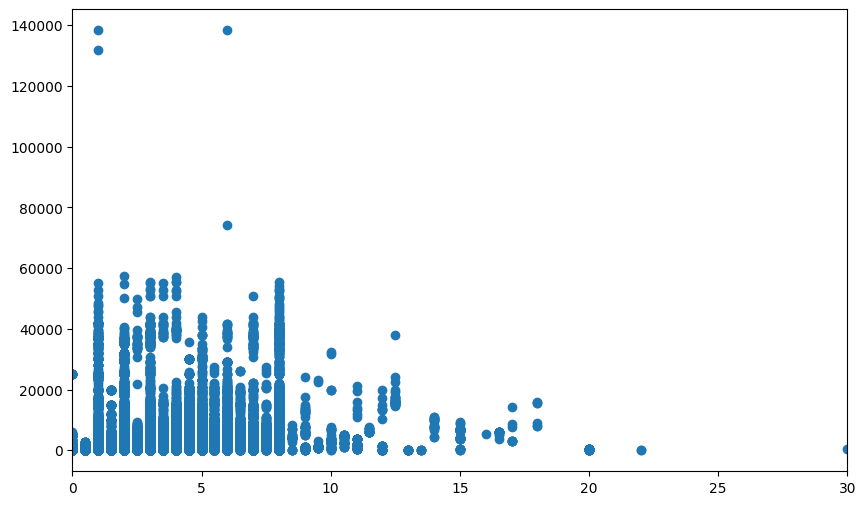

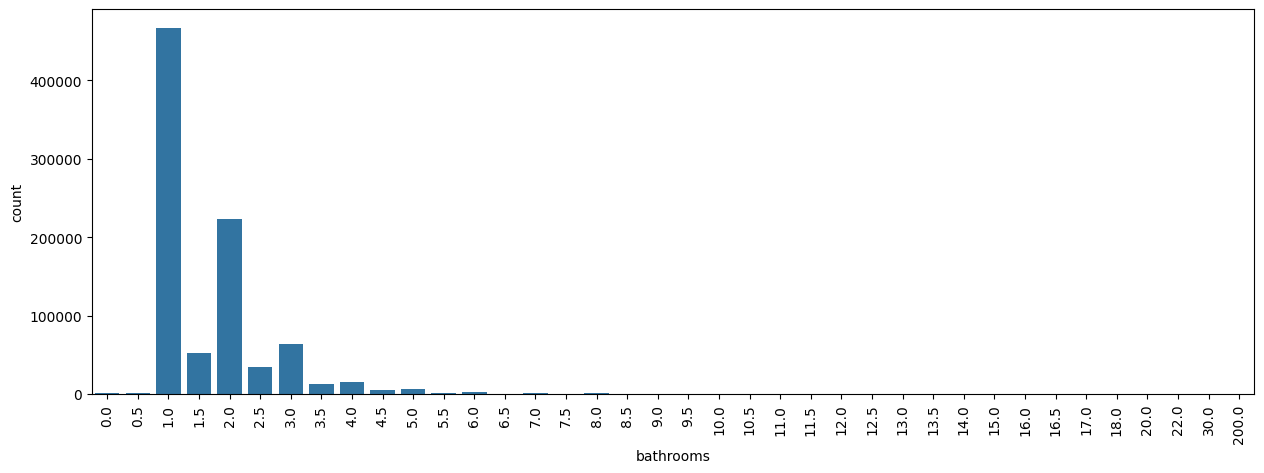

In [44]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['bathrooms'] , y = df_numericas['price'])
ax.set_xlim(0,30)

plt.show()

bar(df_numericas , 'bathrooms')

In [45]:
novo , qtd = excluir_outliers(analise_df , 'bathrooms')
inf , sup = limites(df_numericas , 'bathrooms')
print(qtd , sup)

41846 3.5


como podemos ver, o limite superior do intervalo interquartílico é de 3.5. Isso quer dizer que se fossemos excluir os outliers, estaríamos excluíndo imóveis com pelo menos 4 banheiros, o que não é um número absurdo de banheiros para um imóvel. Nesse caso, vamos adaptar e excluir imóveis com pelo menos 7 banheiros.

In [46]:
inicial = analise_df.shape[0]
analise_df = analise_df[analise_df['bathrooms'] <= 7]
linhas_excluidas = inicial - analise_df.shape[0]


print(linhas_excluidas)

1080


### bedrooms

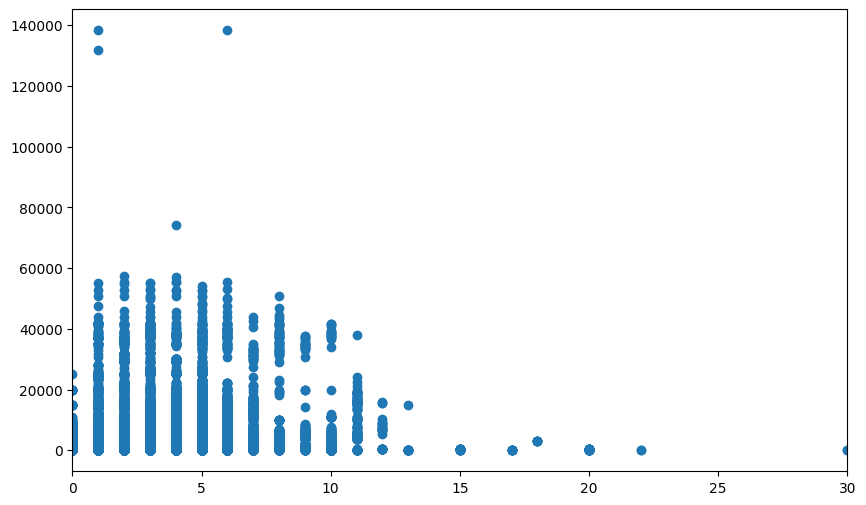

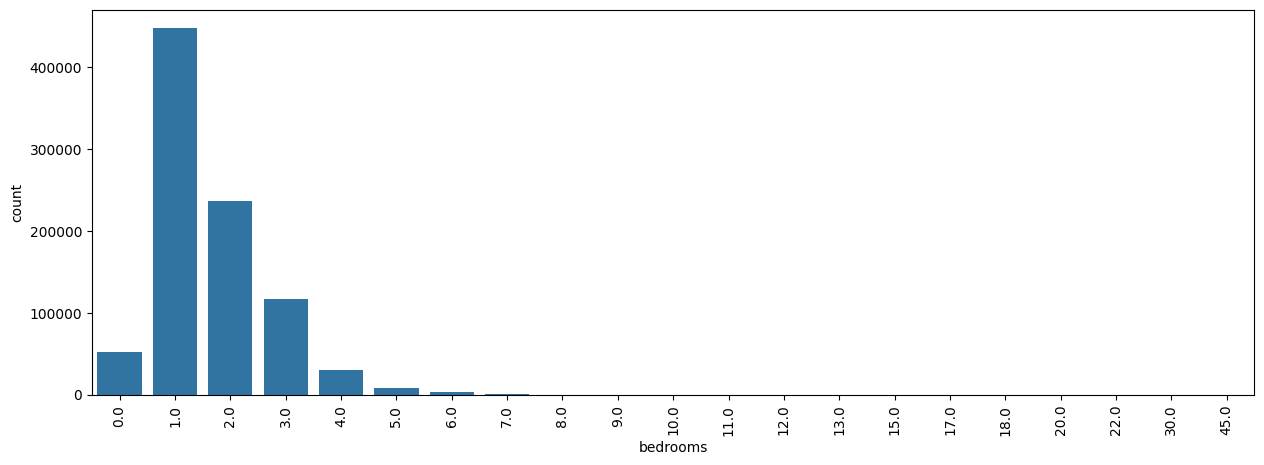

In [47]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['bedrooms'] , y = df_numericas['price'])
ax.set_xlim(0,30)

plt.show()

bar(df_numericas , 'bedrooms')

In [48]:
novo , qtd = excluir_outliers(df_numericas , 'bedrooms')
inf , sup = limites(df_numericas , 'bedrooms')
print(qtd , sup)

44771 3.5


Como podemos ver, o coportamento da variável bedrooms é muito similar ao comportamento da variável bathrooms. Portanto vamos tratar da mesma maneira, considerando imóveis com no máximo 6 quartos para nosso modelo. 

In [49]:
inicial = analise_df.shape[0]
analise_df = analise_df[analise_df['bedrooms'] <= 7]
linhas_excluidas = inicial - analise_df.shape[0]


print(linhas_excluidas)

208


### beds

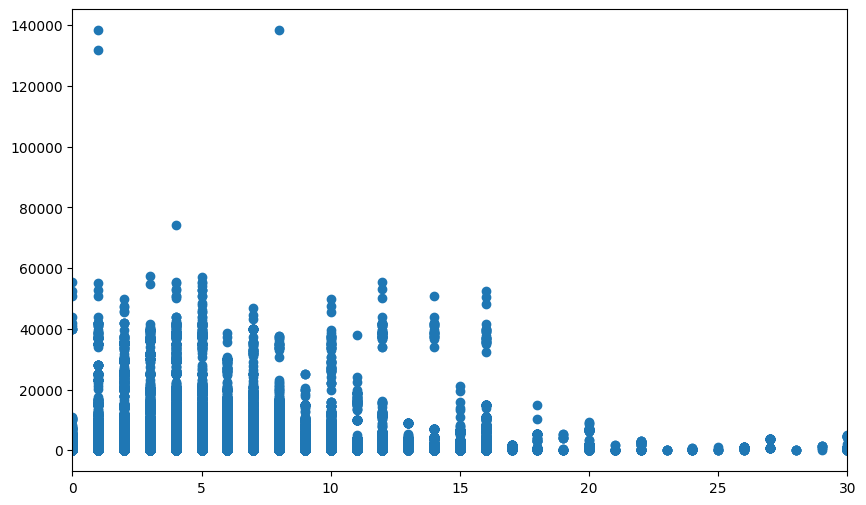

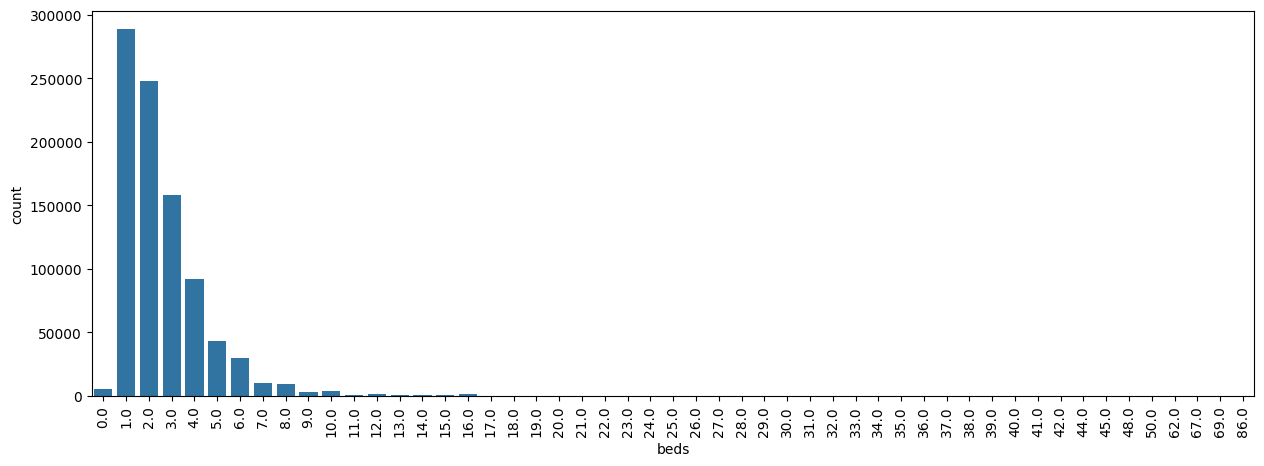

In [50]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['beds'] , y = df_numericas['price'])
ax.set_xlim(0,30)

plt.show()

bar(df_numericas , 'beds')

In [51]:
novo , qtd = excluir_outliers(df_numericas , 'beds')
inf , sup = limites(df_numericas , 'beds')
print(qtd , sup)

62604 6.0


Comportamento muito parecido com as variáveis bathrooms e bedrooms. Vamos considerar nessa variável apenas imóveis com pelo no maximo 10 camas.

In [52]:
inicial = analise_df.shape[0]
analise_df = analise_df[analise_df['beds'] <= 10]
linhas_excluidas = inicial - analise_df.shape[0]


print(linhas_excluidas)

766


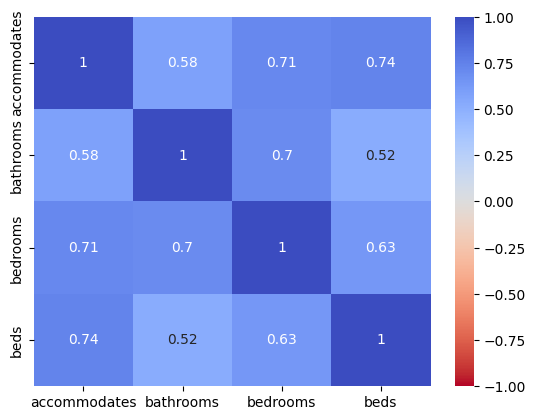

In [53]:
sns.heatmap(analise_df[['accommodates' , 'bathrooms' , 'bedrooms' , 'beds']].corr() , cmap = 'coolwarm_r',  annot = True ,vmin = -1 , vmax = 1);

Observando novamente o mapa de calor, focado nas 4 últimas variáveis que analisamos, podemos perceber que todas entre si possuem um coeficiente de correlação linear relativamente alto. Portanto, vamos levar em conta para nosso modelo apenas a variável accommodates.

In [54]:
analise_df = analise_df.drop(columns = ['bathrooms' , 'bedrooms' , 'beds' , 'host_is_superhost'])
analise_df.columns

Index(['host_listings_count', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'price', 'security_deposit',
       'cleaning_fee', 'guests_included', 'extra_people', 'minimum_nights',
       'number_of_reviews', 'review_scores_rating', 'review_scores_location',
       'instant_bookable', 'is_business_travel_ready', 'cancellation_policy',
       'mes', 'ano'],
      dtype='str')

### security_deposit

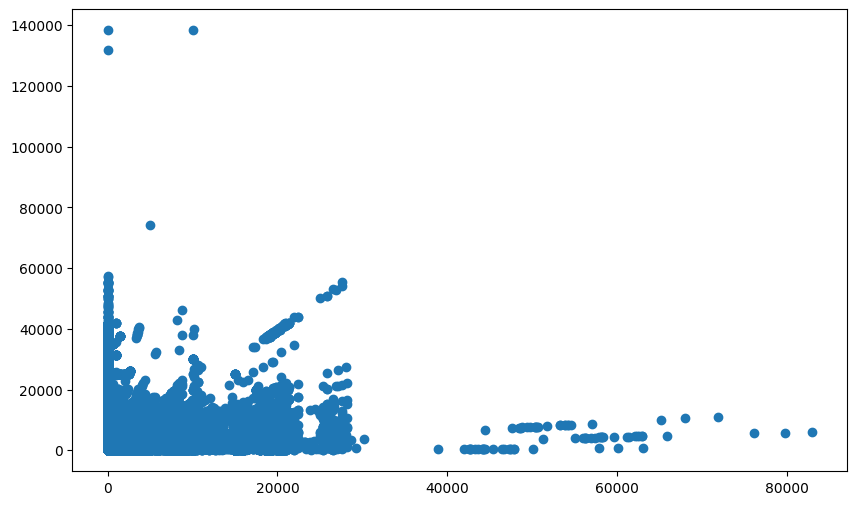

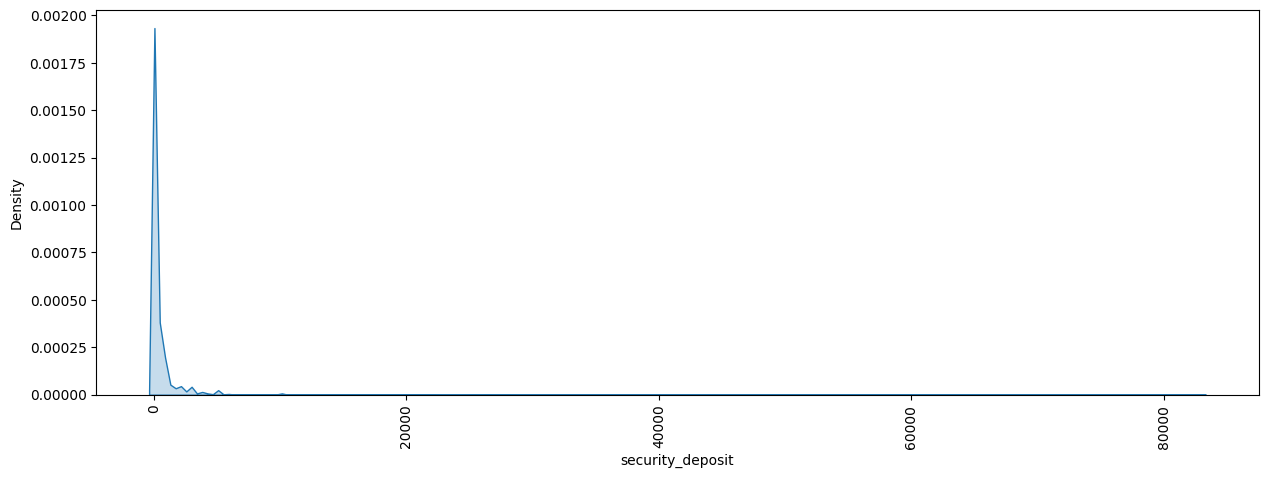

In [55]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['security_deposit'] , y = df_numericas['price'])

plt.show()

distribuicao(df_numericas , 'security_deposit' , hist = False , hue = None)

In [56]:
novo, linhas = excluir_outliers(df_numericas , 'security_deposit')
inf , sup = limites(df_numericas,'security_deposit')
print(linhas, sup)

106361 1250.0


O scatterplot mostra alguns pontos cobrando um valor de deposito de segurança acima do valor do preço do imóvel, o que não faz sentido. Vamos excluir as linhas onde isso ocorre. 

In [57]:
novo = df_numericas[df_numericas['security_deposit'] < df_numericas['price']]
print(novo.shape[0])

613296


Observe que mais de 25% das linhas do dataframe possui um valor de deposito de segurança maior que o preço. Por isso não vamos levar essa variável em consideração.

In [58]:
analise_df = analise_df.drop(columns = 'security_deposit')

### cleaning_fee

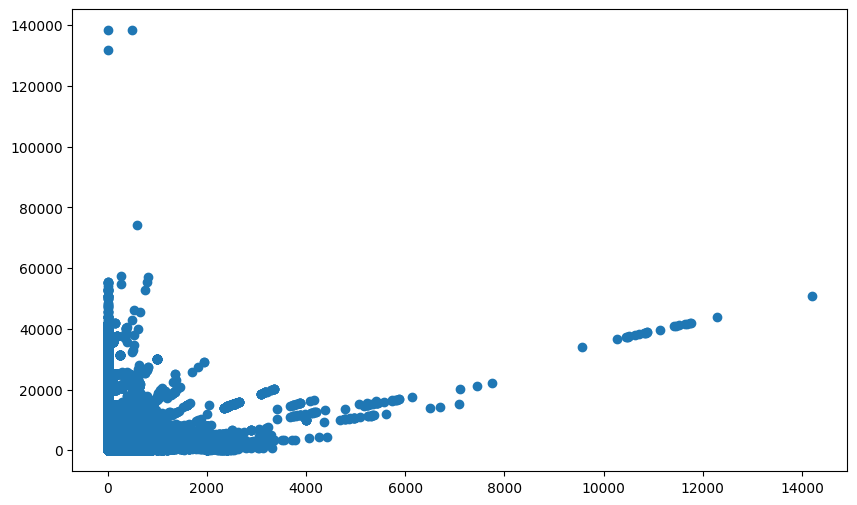

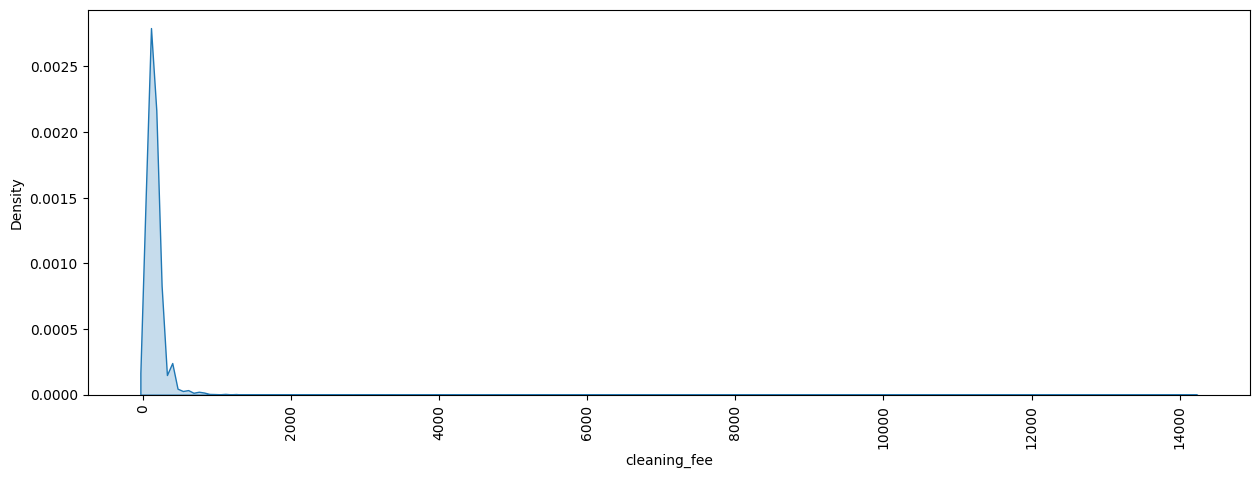

In [59]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['cleaning_fee'] , y = df_numericas['price'])

plt.show()

distribuicao(df_numericas , 'cleaning_fee' , hist = False, hue =None )

In [60]:
novo , linhas = excluir_outliers(analise_df , 'cleaning_fee')
print(linhas)

22979


Pelo scatterplot , o preço parece aumentar quando a taxa de limpeza aumenta. Como essa variável não possui um número significativo de outliers, vamos excluí-los de nossos modelos.

In [61]:
analise_df , linhas = excluir_outliers(analise_df , 'cleaning_fee')
print(analise_df.shape[0])

854599


### guests _included

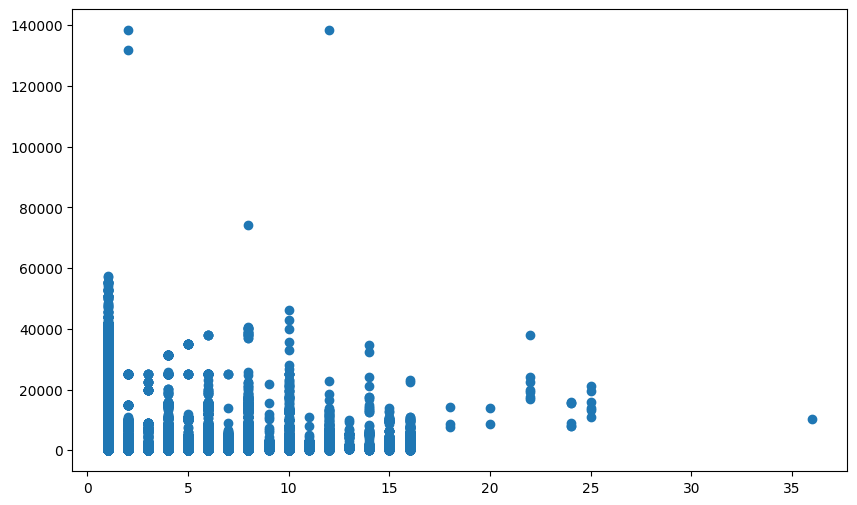

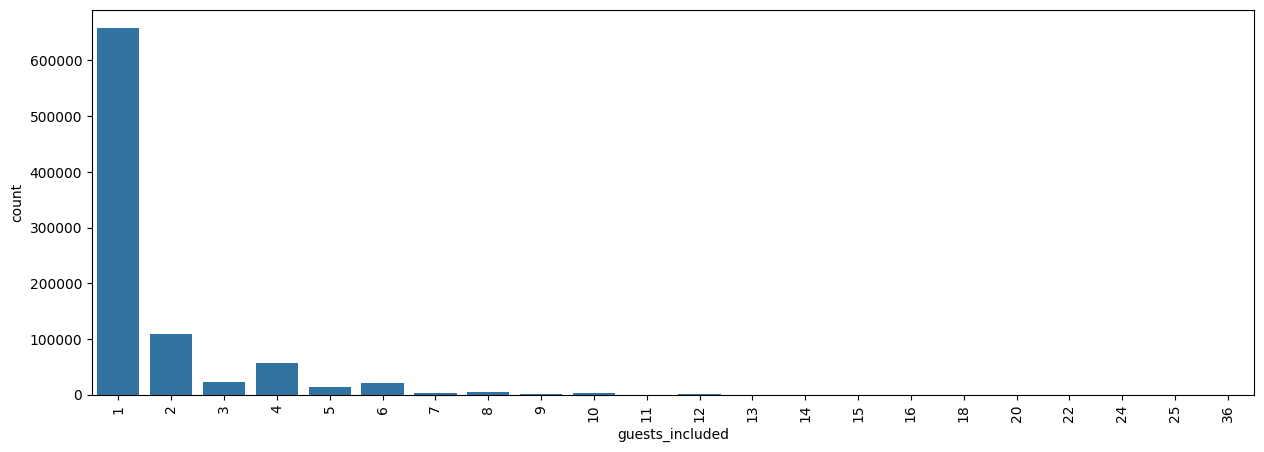

In [62]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['guests_included'] , y = df_numericas['price'])

plt.show()

bar(df_numericas , 'guests_included')

Podemos ver que a grande maioria dos host preencheu com 1 convidado. Por isso vamos excluir a coluna das nossas análises.

In [63]:
analise_df = analise_df.drop(columns = 'guests_included')

### extra people

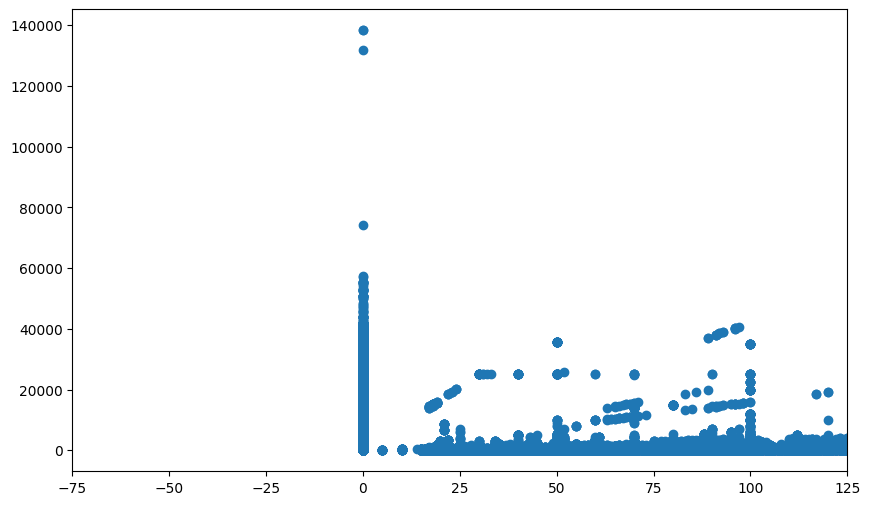

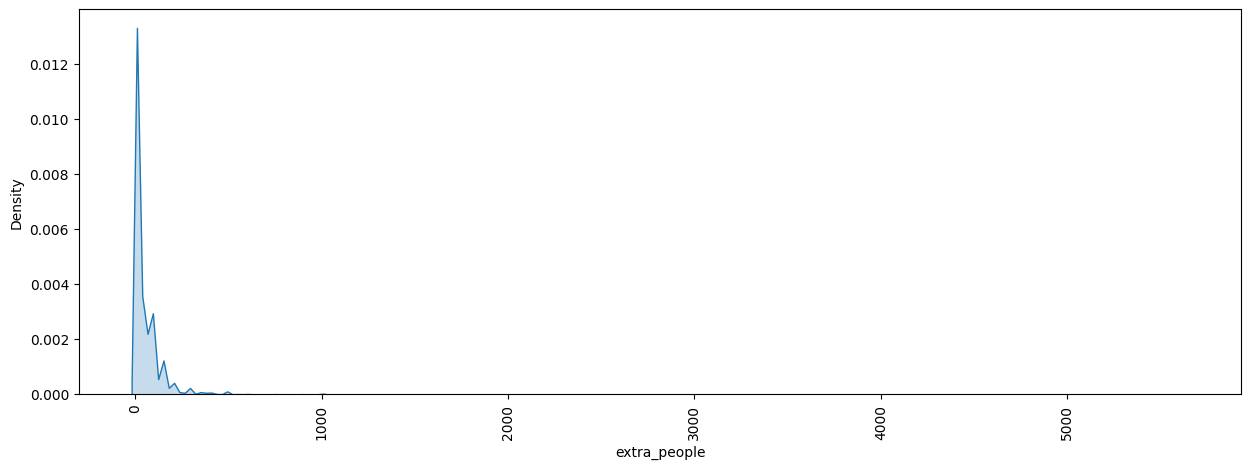

In [64]:
fig , ax = plt.subplots(figsize = (10 , 6))
ax1 = plt.scatter(x = df_numericas['extra_people'] , y = df_numericas['price'])
ax.set_xlim(limites(df_numericas , 'extra_people'))

plt.show()

distribuicao(df_numericas , 'extra_people' , hist = False, hue =None)

In [65]:
novo , linhas = excluir_outliers(df_numericas, 'extra_people')
print(linhas)

70454


Mesmo observando no intervalo interquartílico, a variável não parece influenciar o preço do imóvel.  

### minimum nigths

In [66]:
inf , sup = limites(df_numericas , 'minimum_nights')
novo , linhas = excluir_outliers(df_numericas , 'minimum_nights')
print(sup , linhas)

8.5 68735


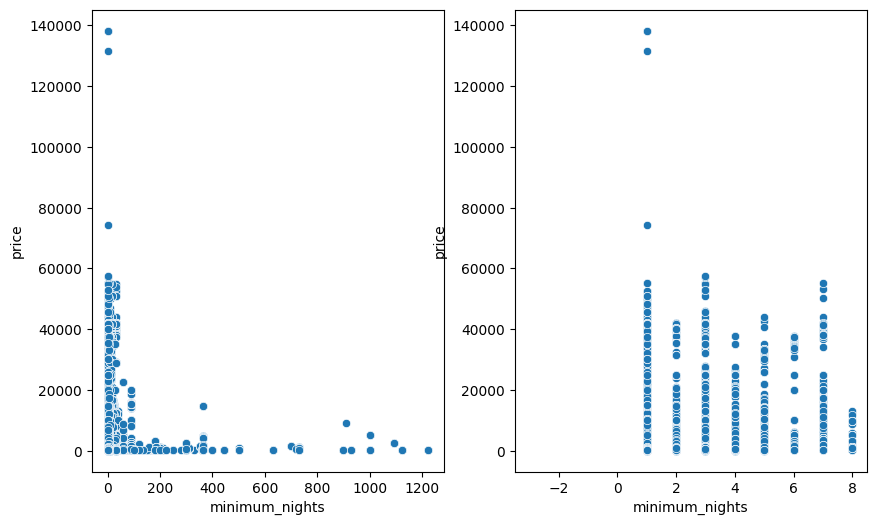

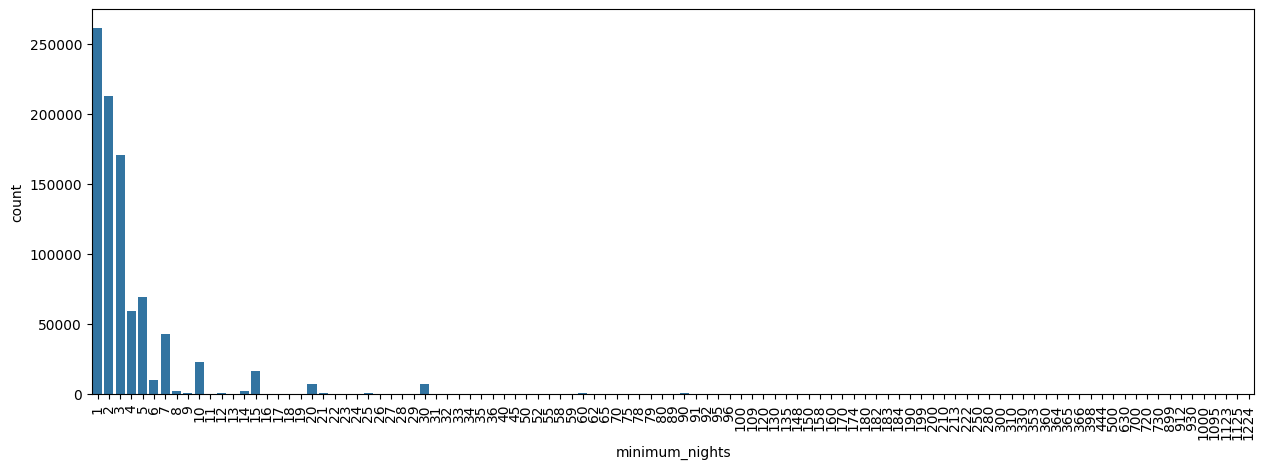

In [67]:
fig , ax = plt.subplots(figsize = (10 , 6)  ,nrows =1 , ncols= 2)
ax0 =sns.scatterplot(x = df_numericas['minimum_nights'] , y = df_numericas['price'] , ax = ax[0])
ax1 = sns.scatterplot(x = df_numericas['minimum_nights'] , y = df_numericas['price'] , ax = ax[1])
ax[1].set_xlim(limites(df_numericas , 'minimum_nights'))

plt.show()

bar(df_numericas , 'minimum_nights')

Para minimum nights, vamos optar por excluir linhas com mais de 8.5, que é o limite superior do intervalo interquartílico. 

In [68]:
analise_df , linhas = excluir_outliers(analise_df , 'minimum_nights')

### number of reviews

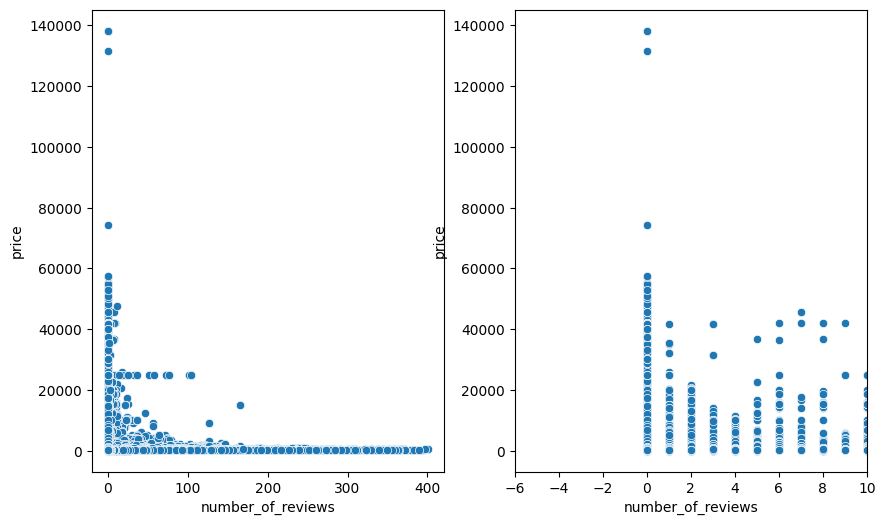

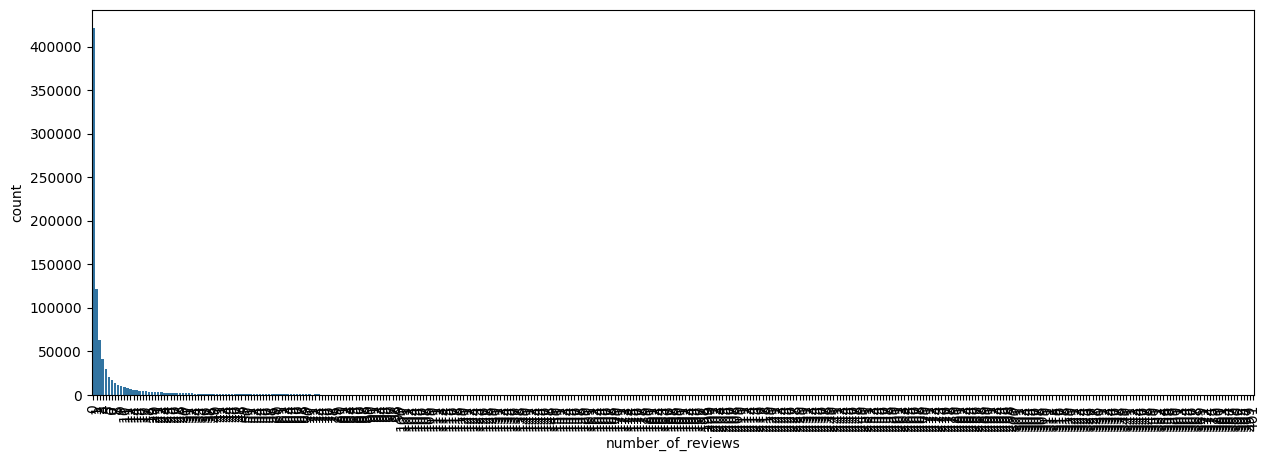

In [69]:
fig , ax = plt.subplots(figsize = (10 , 6)  ,nrows =1 , ncols= 2)
ax0 =sns.scatterplot(x = df_numericas['number_of_reviews'] , y = df_numericas['price'] , ax = ax[0])
ax1 = sns.scatterplot(x = df_numericas['number_of_reviews'] , y = df_numericas['price'] , ax = ax[1])
ax[1].set_xlim(limites(df_numericas , 'number_of_reviews'))

plt.show()

bar(df_numericas , 'number_of_reviews')

Como a maior parte dos hosts possui menos de 10 avaliações , vamos excluir essa variável de nossos modelos

In [70]:
analise_df = analise_df.drop(columns = 'number_of_reviews')

 Tendo em vista que não consideramos a variável number_of_reviews, e, pelo boxplot das variáveis de avaliação, podemos ver que há uma densidade muito grande de avaliações com notas acima de nove. Com esse fator, aliado ao número baixo de reviews na grande maioria do dataset, vamos também excluir essas duas variáveis de nossos modelos.

In [71]:
analise_df = analise_df.drop(columns = ['review_scores_rating' , 'review_scores_location'])

Antes de partir para analise de séries temporais com as colunas de ano e mês, vamos avaliar novamente a coluna de tipos de casas

In [72]:
display(analise_df['property_type'].value_counts())

property_type
Apartment                 618802
House                      73826
Condominium                35653
Serviced apartment         18516
Loft                       14991
Bed and breakfast           5365
Guest suite                 4522
Hostel                      4254
Other                       2782
Guesthouse                  2776
Villa                       1824
Townhouse                   1502
Hotel                       1410
Aparthotel                  1292
Boutique hotel               738
Chalet                       600
Earth house                  562
Tiny house                   528
Cottage                      477
Boat                         399
Casa particular (Cuba)       335
Bungalow                     267
Dorm                         220
Cabin                        181
Nature lodge                 152
Castle                       145
Treehouse                     76
Island                        64
Resort                        44
Hut                          

Vamos agrupar todas os tipos de casa com menos do que 'Other'.

In [73]:
tabela_tipos = analise_df['property_type'].value_counts()
agrupar = []

for tipo in tabela_tipos.index:
    if tabela_tipos[tipo] < tabela_tipos['Other']:
        agrupar.append(tipo)

print(agrupar)


for tipo in agrupar:
    analise_df.loc[analise_df['property_type'] == tipo , 'property_type'] = 'Other'


['Guesthouse', 'Villa', 'Townhouse', 'Hotel', 'Aparthotel', 'Boutique hotel', 'Chalet', 'Earth house', 'Tiny house', 'Cottage', 'Boat', 'Casa particular (Cuba)', 'Bungalow', 'Dorm', 'Cabin', 'Nature lodge', 'Castle', 'Treehouse', 'Island', 'Resort', 'Hut', 'Campsite', 'Camper/RV', 'Farm stay', 'Yurt', 'Tent', 'Tipi', 'Vacation home', 'Barn', 'Dome house', 'Pension (South Korea)', 'Parking Space', 'In-law', 'Pousada', 'Igloo', 'Train', 'Timeshare', 'Houseboat', 'Casa particular', 'Plane']


In [74]:
display(analise_df['property_type'].value_counts())

property_type
Apartment             618802
House                  73826
Condominium            35653
Serviced apartment     18516
Other                  16653
Loft                   14991
Bed and breakfast       5365
Guest suite             4522
Hostel                  4254
Name: count, dtype: int64

Vamos fazer o mesmo para a variável cancellation policy

In [75]:
tabela_tipos = analise_df['cancellation_policy'].value_counts()
agrupar = []

for tipo in tabela_tipos.index:
    if tabela_tipos[tipo] < tabela_tipos['strict']:
        agrupar.append(tipo)

print(agrupar)

for tipo in agrupar:
    analise_df.loc[analise_df['cancellation_policy'] == tipo , 'cancellation_policy'] = 'strict'

print(analise_df['cancellation_policy'].value_counts())


['super_strict_60', 'super_strict_30']
cancellation_policy
flexible                       332599
strict_14_with_grace_period    297205
moderate                       138774
strict                          24004
Name: count, dtype: int64


Vamos agora analisar as colunas de ano e mês. Para isso, vamos plotar um gráfico de linha para analisar se há algum tipo de padrão sazonal.

In [76]:
analise_df['mes_ano'] = pd.to_datetime(analise_df['ano'].astype(int).astype(str) + '-' + analise_df['mes'] + '-01').dt.to_period('M')
display(analise_df.head())


,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,price,cleaning_fee,extra_people,minimum_nights,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano,mes_ano
1,2.0,f,Copacabana,-22.965919,-43.178962,Condominium,Entire home/apt,5,270.0,273.0,51.0,4,t,f,strict,04,2018.0,2018-04
2,1.0,t,Ipanema,-22.985698,-43.201935,Apartment,Entire home/apt,2,222.0,211.0,215.0,3,f,f,strict,04,2018.0,2018-04
3,3.0,t,Copacabana,-22.977117,-43.190454,Apartment,Entire home/apt,3,161.0,220.0,45.0,4,f,f,strict,04,2018.0,2018-04
4,1.0,t,Ipanema,-22.983024,-43.214270,Apartment,Entire home/apt,3,222.0,85.0,68.0,2,t,f,strict,04,2018.0,2018-04
5,1.0,t,Ipanema,-22.988165,-43.193588,Apartment,Entire home/apt,3,308.0,158.0,86.0,2,f,f,strict,04,2018.0,2018-04


In [77]:
display(analise_df['mes_ano'].value_counts())

mes_ano
2018-04    35644
2018-05    35369
2018-07    34593
2018-08    33566
2018-09    32572
2020-02    32030
2019-03    32011
2018-10    31776
2019-02    31745
2019-04    31720
2020-03    31489
2019-05    31463
2019-06    31324
2018-12    31280
2019-07    31228
2018-11    31111
2020-04    31109
2019-01    30992
2020-05    30887
2019-08    30626
2020-01    30536
2019-12    30299
2019-09    30120
2019-11    29553
2019-10    29539
Freq: M, Name: count, dtype: int64

In [78]:
series_temporais = analise_df[['price' , 'mes_ano']].groupby('mes_ano' , as_index = False).mean()
display(series_temporais)

,mes_ano,price
0,2018-04,491.389855
1,2018-05,497.189742
2,2018-07,495.408349
3,2018-08,500.273104
4,2018-09,512.910383
5,2018-10,499.526844
6,2018-11,506.981839
7,2018-12,514.497027
8,2019-01,503.188823
9,2019-02,507.732525


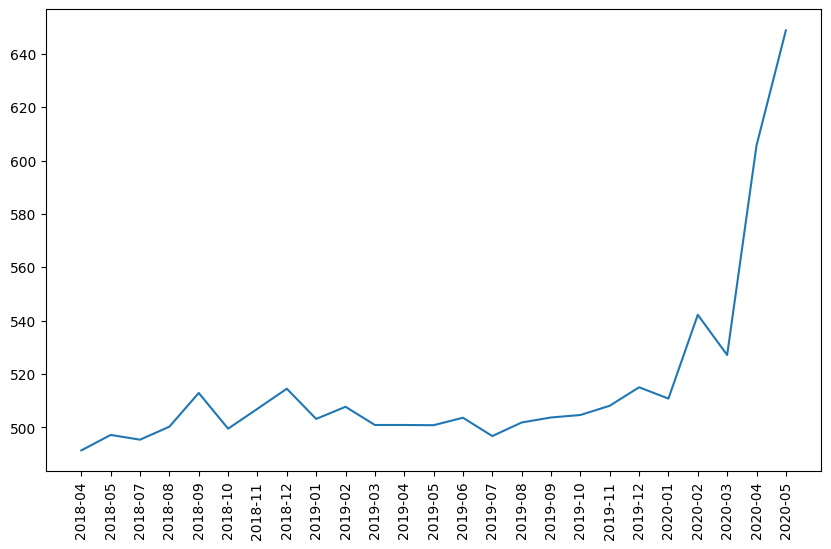

In [79]:
fig , ax = plt.subplots(figsize = (10 , 6))
ex = ax.plot(series_temporais['mes_ano'].astype(str) , series_temporais['price'])
ax.tick_params(axis = 'x' , rotation = 90)

plt.show()

Pelo gráfico acima da série temporal para os preços médios dos imóveis no Airbnb, podemos perceber primeiramente pelos anos de 2018 e 2019 que os preços costumam subir no fim do ano/começo do ano, e ao longo do ano os preços voltam a ter uma leve recaída. Isso pode ser explicado pela temporada de verão/férias. Nesse período, os imóveis custumam ser mais vizados, o que pode valorizar o preço do aluguel. Outra fato que podemos observar é que em 2020 os preços aumentaram bruscamente, independente da temporada. Isso pode ser explicado pela pendemia, onde o mundo passou por uma crise economica.

### Avaliando latitude e longitude

In [80]:
visualizacao , linhas = excluir_outliers(analise_df , 'price')
amostra = visualizacao.sample(n = 50000)
centro = {
    'lat' : amostra['latitude'].mean(),
    'lon' : amostra['longitude'].mean()
}

mapa = px.density_mapbox(amostra , lat = 'latitude' , lon = 'longitude' , z = 'price' , radius = 2.5 , 
                         center = centro , zoom = 10 , mapbox_style = 'open-street-map');
mapa.show()

C:\Users\vitor\AppData\Local\Temp\ipykernel_5124\188571345.py:8: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  mapa = px.density_mapbox(amostra , lat = 'latitude' , lon = 'longitude' , z = 'price' , radius = 2.5 ,


O mapa acima é mais uma evidencia, junto com o boxplot das médias de preços por bairros, que a localização de um imóvel é um fator que possui forte influência no preço do mesmo.

# Encoding

Precisamos ajustar as features categóricas do nosso modelos para variáveis numéricas


### Encoding true or false

- Vamos substituir por valores 1 ou 0

In [81]:
print(analise_df.columns)
colunas_tf = ['host_identity_verified' , 'instant_bookable' , 'is_business_travel_ready']
base_cod = analise_df.copy()

base_cod[colunas_tf] = base_cod[colunas_tf].replace({'t': 1, 'f': 0})

Index(['host_listings_count', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'price', 'cleaning_fee', 'extra_people',
       'minimum_nights', 'instant_bookable', 'is_business_travel_ready',
       'cancellation_policy', 'mes', 'ano', 'mes_ano'],
      dtype='str')


### Encoding de features categóricas

In [82]:
print(df_categoricas.columns)
categoricas = ['neighbourhood_cleansed' , 'property_type' , 'room_type' , 'cancellation_policy']
bairros = base_cod['neighbourhood_cleansed'].value_counts()
display(np.where(bairros.values > 5000 ))

Other = []

for bairro in bairros.index:
    if bairros[bairro] < 5000:
        Other.append(bairro)

for var in Other:
    base_cod.loc[base_cod['neighbourhood_cleansed'] == var , 'neighbourhood_cleansed'] = 'Other'

print(base_cod['neighbourhood_cleansed'].value_counts())

base_cod = pd.get_dummies(data = base_cod , columns = categoricas)

display(base_cod.shape)

Index(['host_is_superhost', 'host_identity_verified', 'neighbourhood_cleansed',
       'property_type', 'room_type', 'instant_bookable',
       'is_business_travel_ready', 'cancellation_policy', 'mes'],
      dtype='str')


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23]),)

neighbourhood_cleansed
Copacabana                  207381
Barra da Tijuca              82420
Other                        81744
Ipanema                      68647
Jacarepaguá                  40665
Botafogo                     40637
Leblon                       37167
Recreio dos Bandeirantes     36760
Santa Teresa                 27314
Centro                       23118
Flamengo                     21409
Laranjeiras                  17395
Tijuca                       17389
Leme                         14631
Lagoa                         8840
Catete                        8184
Glória                        7713
Jardim Botânico               7565
Gávea                         7207
Humaitá                       7081
Maracanã                      6581
Vila Isabel                   6484
Camorim                       5748
São Conrado                   5472
Freguesia (Jacarepaguá)       5030
Name: count, dtype: int64


(792582, 56)

# Modelos

Vamos montar usar modelos de regressão para prever o preço do Airbnb. Para isso ,vamos usar os seguintes modelos para avaliar quais tem melhores resultados de acordo com as métricas $R^2$, MSE, MAE: Modelos de Regressão linear, modelos de random forest, decision Tree e  Extra Tree. 



In [ ]:
def avaliar_modelo(nome_modelo, y_test , y_pred):
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test , y_pred)
    mae = mean_absolute_error(y_test , y_pred)
    return f"""O modelo {nome_modelo} obteve os seguintes resultados:
R2  : {r2:.4f}
MSE : {mse:.2f}
MAE : {mae:.2f}"""
